In [2]:
#LOAD DATA AND PREPROCESSING
import pandas as pd
import numpy as np
import ast

# === STEP 1: LOAD & RENAME ===
data_path = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/20251023-s288c-annotated-PPI-net.pkl"
df = pd.read_pickle(data_path)

# === STEP 2: SUBSET AND CLEAN ===
selected_columns = df[[
    'node', '_wkshell', 'Y2H_wkshell',
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'closeness_centrality',
    'load_centrality', 'pagerank', 'information_centrality',
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality',
    'DeepTMHMM_class', 'signalP_trimmed_sequence',
    'IDR_count', 'N_aa_disordered', 'disorder_fraction',
    'is_disordered_0.05', 'is_disordered_0.10', 'is_disordered_0.15', 'is_disordered_0.20', 'is_disordered_0.25', 'is_disordered_0.30', 'is_disordered_0.35', 
    'is_disordered_0.40', 'is_disordered_0.45', 'is_disordered_0.50', 'is_disordered_0.55', 'is_disordered_0.60', 'is_disordered_0.65', 'is_disordered_0.70', 
    'is_disordered_0.75', 'is_disordered_0.80', 'is_disordered_0.85', 'is_disordered_0.90', 'is_disordered_0.95', 'is_disordered_1.00',
    'mean_plddt', 'L', 
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy',
    'Christiano_degradation_rate(min-1)', 'Villen_halflife_min',
    'mean_molecules_per_cell', 'median_molecules_per_cell', 'log2_TE',
    'interacting_chaperones', 'in_complex', 'Pfam_Ndomains', 
    'essential',  
    'sequence', 'structure_exists', 'sequence_matches_structure', 'meltome-melting-point', 'meltome-fit-R2'
       
]].copy()

# Multiply 'cagiada-dG' by -1 (flip sign)
selected_columns['cagiada-dG'] = pd.to_numeric(selected_columns['cagiada-dG'], errors='coerce') * -1
selected_columns['FoldX_best_total_energy'] = pd.to_numeric(selected_columns['FoldX_best_total_energy'], errors='coerce') * -1

# Replace infinite values with NaN to allow proper cleaning
selected_columns.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fix Pfam_Ndomains: replace empty/NaN with 0
selected_columns['Pfam_Ndomains'] = selected_columns['Pfam_Ndomains'].fillna(0).astype(int)

# === STEP 3: DERIVED FEATURES ===
selected_columns['Length'] = selected_columns['signalP_trimmed_sequence'].fillna('').apply(len)

# Add percentile columns for all centrality metrics
ms_centrality_cols = [
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality',
    'closeness_centrality', 'load_centrality', 'pagerank', 'information_centrality'
]
y2h_centrality_cols = [
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality'
]

# Rename MS columns
ms_rename_map = {col: "MS_" + col for col in ms_centrality_cols}
selected_columns.rename(columns=ms_rename_map, inplace=True)

# Add percentiles for MS-based metrics
for col in ms_centrality_cols:
    ms_col = "MS_" + col
    selected_columns[f"{ms_col}_percentile"] = selected_columns[ms_col].rank(pct=True) * 100

# Add percentiles for Y2H-based metrics
for col in y2h_centrality_cols:
    selected_columns[f"{col}_percentile"] = selected_columns[col].rank(pct=True) * 100

# === STEP 4: ONE HOT ENCODING FOR CHAPERONES ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

selected_columns['interacting_chaperones'] = selected_columns['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

selected_columns['chaperone_category'] = selected_columns.apply(chaperone_category, axis=1)
selected_columns['is_chaperone'] = (selected_columns['chaperone_category'] == 'protein_is_chaperone').astype(int)
selected_columns['interacts_with_chaperone'] = (selected_columns['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
selected_columns['neither_chaperone_nor_interacts'] = (selected_columns['chaperone_category'] == 'protein_is_neither_chpaerone_nor_interacts').astype(int)

# === STEP 5: Match seq and structure nodes ===
selected_columns.info()
selected_columns = selected_columns[~selected_columns["sequence"].isna()]
print (f"Number of nodes with sequence information: {selected_columns.shape[0]}")

# record those nodes that do not have sequence information
no_seq_nodes = selected_columns[selected_columns["sequence"].isna()]
print (f"Number of nodes without sequence information: {no_seq_nodes.shape[0]}")

# remove nodes with no structure from AF2
selected_columns = selected_columns[selected_columns["structure_exists"] == 1]
print (f"Number of nodes with sequence & structure information: {selected_columns.shape[0]}")

# a small number of nodes have an AF2 structure, but its sequence does not match the sequence information from SGD - we can filter those out as well
selected_columns = selected_columns[selected_columns["sequence_matches_structure"] == True]
print (f"Number of nodes with sequence, structure, and matching information between the two: {selected_columns.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 81 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   node                                   3927 non-null   object 
 1   _wkshell                               3927 non-null   int64  
 2   Y2H_wkshell                            1465 non-null   float64
 3   MS_degree_centrality                   3927 non-null   float64
 4   MS_betweenness_centrality              3927 non-null   float64
 5   MS_eigenvector_centrality              3927 non-null   float64
 6   MS_closeness_centrality                3927 non-null   float64
 7   MS_load_centrality                     3927 non-null   float64
 8   MS_pagerank                            3927 non-null   float64
 9   MS_information_centrality              3927 non-null   float64
 10  Y2H_degree_centrality                  1465 non-null   float64
 11  Y2H_

/tmp/ipykernel_2335272/3047752126.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_s1.groupby('plddt_category')[['N_aa_disordered', 'disorder_fraction']].median())
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = d

                N_aa_disordered  disorder_fraction
plddt_category                                    
Very Low (<50)            662.5           0.904111
Low (50-70)               318.0           0.562426
High (≥70)                 42.5           0.110072
Number of proteins per category:
plddt_category
High (≥70)        2958
Low (50-70)        845
Very Low (<50)      56
Name: count, dtype: int64
P-values for N_aa_disordered: {'Very Low (<50) vs. Low (50-70)': np.float64(1.0205832110795115e-09), 'Very Low (<50) vs. High (≥70)': np.float64(4.106800439208385e-33), 'Low (50-70) vs. High (≥70)': np.float64(0.0)}
P-values for disorder_fraction: {'Very Low (<50) vs. Low (50-70)': np.float64(3.9850989984157815e-16), 'Very Low (<50) vs. High (≥70)': np.float64(2.7023035429308858e-33), 'Low (50-70) vs. High (≥70)': np.float64(0.0)}


<Figure size 1920x1440 with 0 Axes>

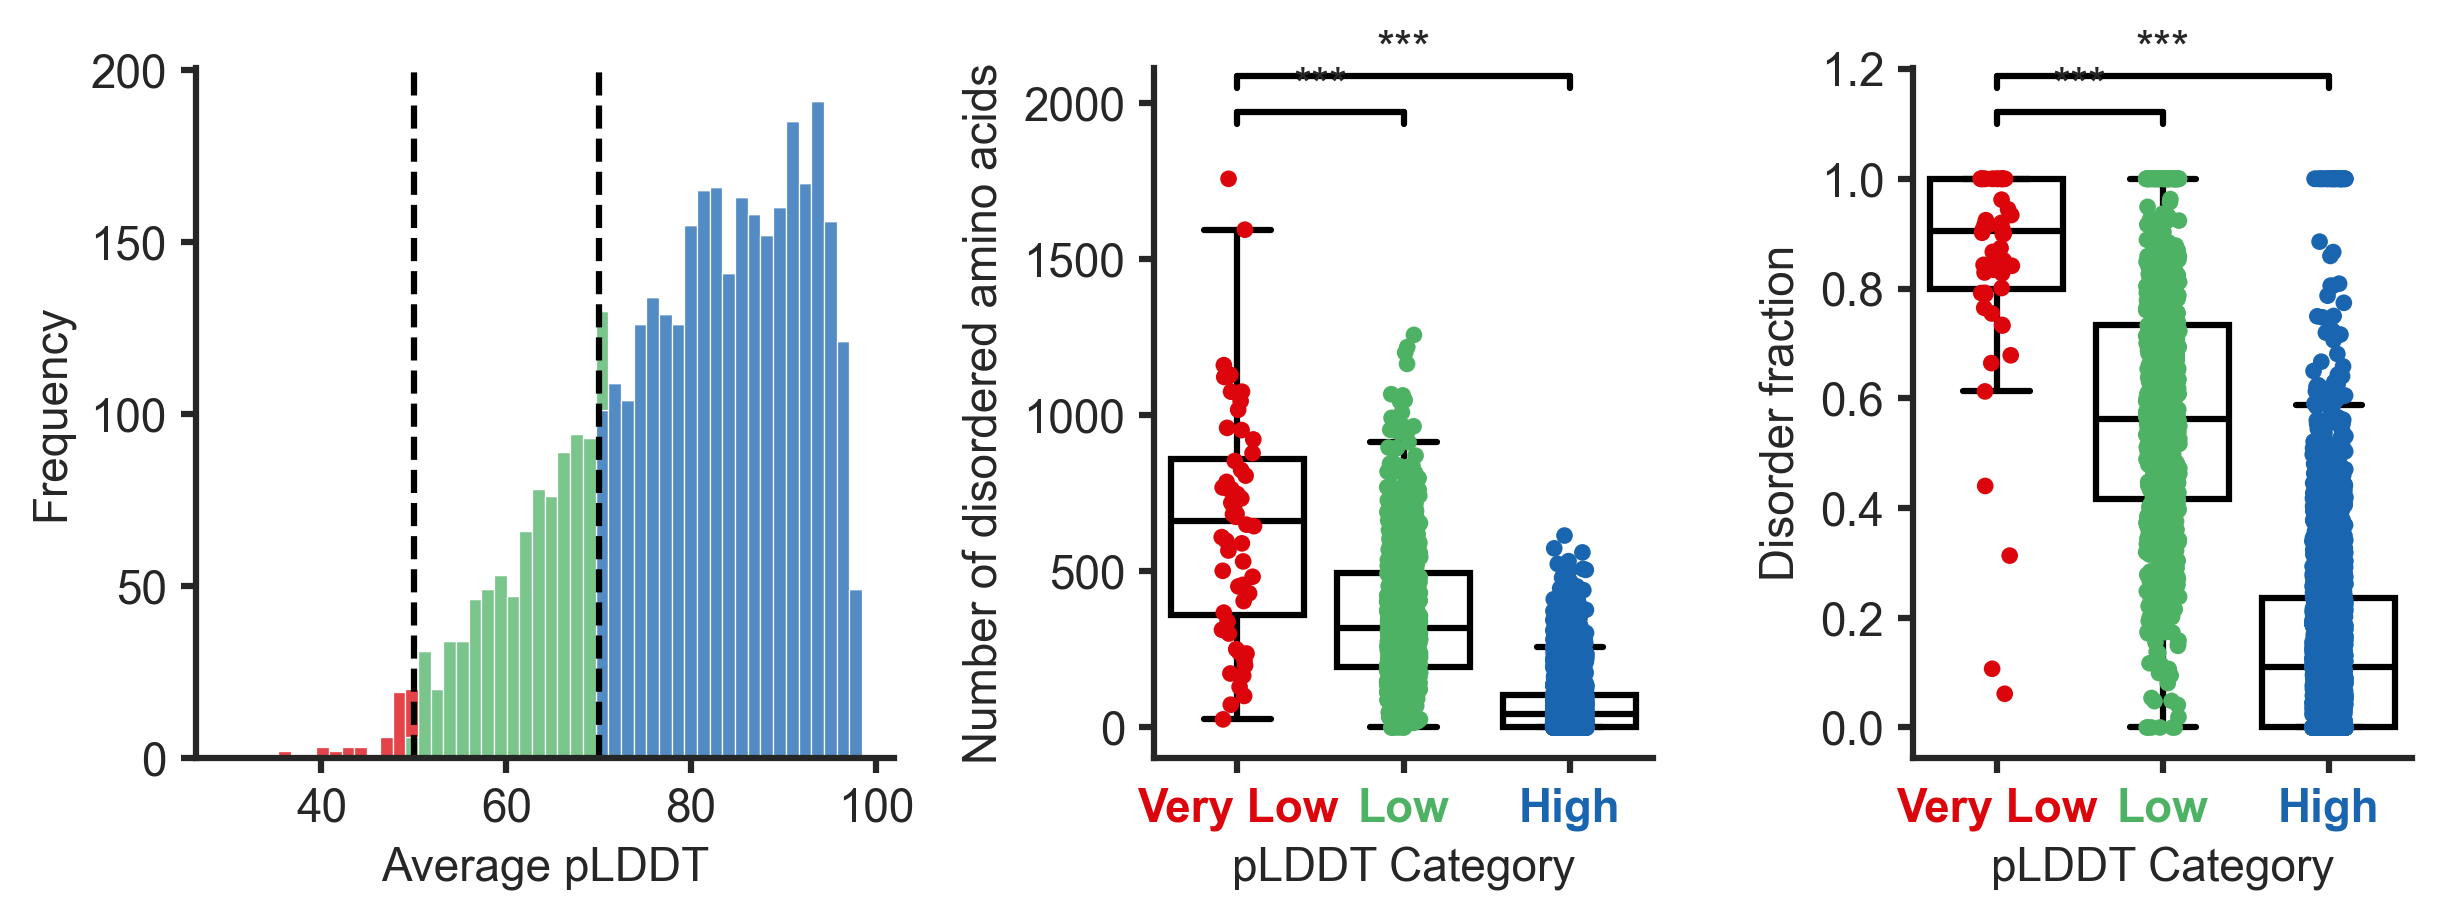

In [3]:
# IMPORT PLOTTING LIBRARIES (add these after your existing imports)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# === GLOBAL PLOT SETTINGS ===
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.5,       # <-- thicker axes lines
    'figure.dpi': 300,
})

sns.set_style('ticks')  # clean, publication look
sns.despine(trim=True)  # removes top/right spines automatically

# Function to get significance stars from p-value
def get_sig_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'
# Function to add significance bar
# --- Replace your significance bar function and calls with this ---
def add_sig_bar(ax, x1, x2, y, stars='ns', bar_height=0.05, text_offset=0.01, text_y_override=None):
    # Draw main bar (horizontal line between x1 and x2)
    ax.plot([x1, x2], [y + bar_height, y + bar_height],
            lw=1.5, c='black', clip_on=False)
    # Draw vertical connectors (short and aligned exactly)
    ax.plot([x1, x1], [y, y + bar_height], lw=1.5, c='black', clip_on=False)
    ax.plot([x2, x2], [y, y + bar_height], lw=1.5, c='black', clip_on=False)
    # Calculate text y-position: default or overridden
    text_y = (y + bar_height + text_offset) if text_y_override is None else text_y_override
    # Add significance stars centered above the bar
    ax.text((x1 + x2) / 2, text_y, stars,
            ha='center', va='bottom', fontfamily='Arial', fontsize=11, clip_on=False)

#PREPARE DATA FOR PREPROCESSING
# Define cutoffs
low_cutoff = 50
high_cutoff = 70
# Filter out NaN mean_plddt if any
df_s1 = selected_columns.dropna(subset=['mean_plddt', 'N_aa_disordered', 'disorder_fraction']).copy()
# Bin categories
cutoffs = [0, low_cutoff, high_cutoff, df_s1['mean_plddt'].max() + 1]
labels = [f'Very Low (<{low_cutoff})', f'Low ({low_cutoff}-{high_cutoff})', f'High (≥{high_cutoff})']
df_s1['plddt_category'] = pd.cut(df_s1['mean_plddt'], bins=cutoffs, labels=labels, right=False)
# Compute group stats (optional, for console output)
print(df_s1.groupby('plddt_category')[['N_aa_disordered', 'disorder_fraction']].median())
print(f"Number of proteins per category:\n{df_s1['plddt_category'].value_counts()}")
# Perform pairwise Mann-Whitney U-tests for significance
categories = labels
p_values_disorder = {}
p_values_fraction = {}
for i in range(len(categories)):
    for j in range(i + 1, len(categories)):
        group1_dis = df_s1[df_s1['plddt_category'] == categories[i]]['N_aa_disordered']
        group2_dis = df_s1[df_s1['plddt_category'] == categories[j]]['N_aa_disordered']
        stat_dis, p_dis = mannwhitneyu(group1_dis, group2_dis)
        p_values_disorder[f"{categories[i]} vs. {categories[j]}"] = p_dis
        
        group1_frac = df_s1[df_s1['plddt_category'] == categories[i]]['disorder_fraction']
        group2_frac = df_s1[df_s1['plddt_category'] == categories[j]]['disorder_fraction']
        stat_frac, p_frac = mannwhitneyu(group1_frac, group2_frac)
        p_values_fraction[f"{categories[i]} vs. {categories[j]}"] = p_frac
print("P-values for N_aa_disordered:", p_values_disorder)
print("P-values for disorder_fraction:", p_values_fraction)

# STEP 7: CREATE MULTI-PANEL FIGURE S1
# === FIGURE LAYOUT (optimized for A4 width, publication) ===
fig, axes = plt.subplots(
    1, 3,
    figsize=(8.27, 3.2),  # ~A4 width (8.27 inches), compact height
    gridspec_kw={'width_ratios': [1.4, 1, 1]}  # histogram wider
)

# Panel A: Histogram of mean_pLDDT with categories and cutoffs
sns.histplot(data=df_s1, x='mean_plddt', hue='plddt_category', multiple='stack', bins=50, ax=axes[0], palette=['#DC050C', '#4EB265', '#1965B0'])
axes[0].axvline(low_cutoff, color='black', linestyle='--', label=f'Cutoff: {low_cutoff}')
axes[0].axvline(high_cutoff, color='black', linestyle='--', label=f'Cutoff: {high_cutoff}')
axes[0].set_xlabel('Average pLDDT')
axes[0].set_ylabel('Frequency')
axes[0].legend().remove()
# Make axes visually consistent
for ax in axes:
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(width=1.5)
# Define colors for consistency
colors = ['#DC050C', '#4EB265', '#1965B0']
# Panel B: Boxplot for N_aa_disordered by category (unfilled black boxes/whiskers)
sns.boxplot(
    data=df_s1,
    x='plddt_category',
    y='N_aa_disordered',
    color='black',
    showcaps=True,
    showfliers=False, # removes diamond outliers
    linewidth=1.5,
    boxprops={'facecolor': 'none', 'edgecolor': 'black'},
    whiskerprops={'color': 'black', 'linewidth': 1.5},
    capprops={'color': 'black', 'linewidth': 1.5},
    medianprops={'color': 'black', 'linewidth': 1.5},
    width=0.8,
    ax=axes[1]
)
# Overlay data points with color and jitter
sns.stripplot(
    data=df_s1,
    x='plddt_category',
    y='N_aa_disordered',
    palette=['#DC050C', '#4EB265', '#1965B0'],
    jitter=True,
    size=4,
    alpha=1
,
    legend=False,
    ax=axes[1]
)
axes[1].set_xlabel('pLDDT Category')
axes[1].set_ylabel('Number of disordered amino acids')
axes[1].set_xticklabels(['Very Low', 'Low', 'High'])
# Make axes visually consistent
for ax in axes:
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(width=1.5)
# Color and bold x-tick labels for Panel B
xticklabels_b = axes[1].get_xticklabels()
for i, label in enumerate(xticklabels_b):
    label.set_color(colors[i])
    label.set_fontweight('bold')
    
# Add significance bars for Panel B (Very Low vs Low, Very Low vs High)
y_max_b = df_s1['N_aa_disordered'].max() * 1.1
h_b = y_max_b * 0.02
text_offset_b = y_max_b * 0.005  # Proportional for consistent visual spacing; adjust multiplier as needed
# Very Low (0) vs Low (1)
p_vl_l_b = p_values_disorder["Very Low (<50) vs. Low (50-70)"]
stars_vl_l_b = get_sig_stars(p_vl_l_b)
add_sig_bar(axes[1], 0, 1, y_max_b, stars=stars_vl_l_b, bar_height=h_b, text_offset=text_offset_b, text_y_override=None)  # Use None for default, or e.g., y_max_b + h_b + 5 for manual higher position

# Very Low (0) vs High (2) - higher bar
p_vl_h_b = p_values_disorder["Very Low (<50) vs. High (≥70)"]
stars_vl_h_b = get_sig_stars(p_vl_h_b)
add_sig_bar(axes[1], 0, 2, y_max_b + h_b * 3, stars=stars_vl_h_b, bar_height=h_b, text_offset=text_offset_b, text_y_override=None)  # Use None for default, or e.g., (y_max_b + h_b * 3) + h_b + 3 for manual

min_y_b = df_s1['N_aa_disordered'].min()
highest_y_b = y_max_b + h_b * 4 + text_offset_b  # Accounts for top of second bar + text
axes[1].set_ylim(min(0, min_y_b - y_max_b * 0.05), highest_y_b + h_b * 0.4)  # Buffer for aesthetics

# Panel C: Boxplot for disorder_fraction by category (unfilled black boxes/whiskers)
sns.boxplot(
    data=df_s1,
    x='plddt_category',
    y='disorder_fraction',
    color='black',
    showcaps=True,
    showfliers=False, # removes diamond outliers
    linewidth=1.5,
    boxprops={'facecolor': 'none', 'edgecolor': 'black'},
    whiskerprops={'color': 'black', 'linewidth': 1.5},
    capprops={'color': 'black', 'linewidth': 1.5},
    medianprops={'color': 'black', 'linewidth': 1.5},
    width=0.8,
    ax=axes[2]
)
# Overlay data points with color and jitter
sns.stripplot(
    data=df_s1,
    x='plddt_category',
    y='disorder_fraction',
    palette=['#DC050C', '#4EB265', '#1965B0'],
    jitter=True,
    size=4,
    alpha=1,
    legend=False,
    ax=axes[2]
)
axes[2].set_xticklabels(['Very Low', 'Low', 'High'])
axes[2].set_xlabel('pLDDT Category')
axes[2].set_ylabel('Disorder fraction')


# Make axes visually consistent
for ax in axes:
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(width=1.5)

# Color and bold x-tick labels for Panel C
xticklabels_c = axes[2].get_xticklabels()
for i, label in enumerate(xticklabels_c):
    label.set_color(colors[i])
    label.set_fontweight('bold')
    
# Add significance bars for Panel C (Very Low vs Low, Very Low vs High)
y_max_c = df_s1['disorder_fraction'].max() * 1.1
h_c = y_max_c * 0.02
text_offset_c = y_max_c * 0.005  # Proportional for consistent visual spacing; adjust multiplier as needed
# Very Low (0) vs Low (1)
p_vl_l_c = p_values_fraction["Very Low (<50) vs. Low (50-70)"]
stars_vl_l_c = get_sig_stars(p_vl_l_c)
add_sig_bar(axes[2], 0, 1, y_max_c, stars=stars_vl_l_c, bar_height=h_c, text_offset=text_offset_c, text_y_override=None)  

# Very Low (0) vs High (2) - higher bar
p_vl_h_c = p_values_fraction["Very Low (<50) vs. High (≥70)"]
stars_vl_h_c = get_sig_stars(p_vl_h_c)
add_sig_bar(axes[2], 0, 2, y_max_c + h_c * 3, stars=stars_vl_h_c, bar_height=h_c, text_offset=text_offset_c, text_y_override=None)  

min_y_c = df_s1['disorder_fraction'].min()
highest_y_c = y_max_c + h_c * 4 + text_offset_c  # Accounts for top of second bar + text
axes[2].set_ylim(min(0, min_y_c - y_max_c * 0.05), highest_y_c + h_c * 0.4)  # Buffer for aesthetics

# Adjust layout and save
plt.tight_layout()
plt.savefig(
    '/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE3/Supp1-plddt-distribution.svg',
    dpi=300, bbox_inches='tight'
)

In [4]:
# Assuming selected_columns is already loaded/defined here
# Filter: Remove low pLDDT and TMD/SP proteins
filtered_df = selected_columns[
    (selected_columns['mean_plddt'] >= 50) &
    (~selected_columns['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Optional: Print stats to verify
print(f"Original rows: {len(selected_columns)}")
print(f"Filtered rows: {len(filtered_df)}")

Original rows: 3859
Filtered rows: 3209


Number of proteins after filtering: 3208


/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated

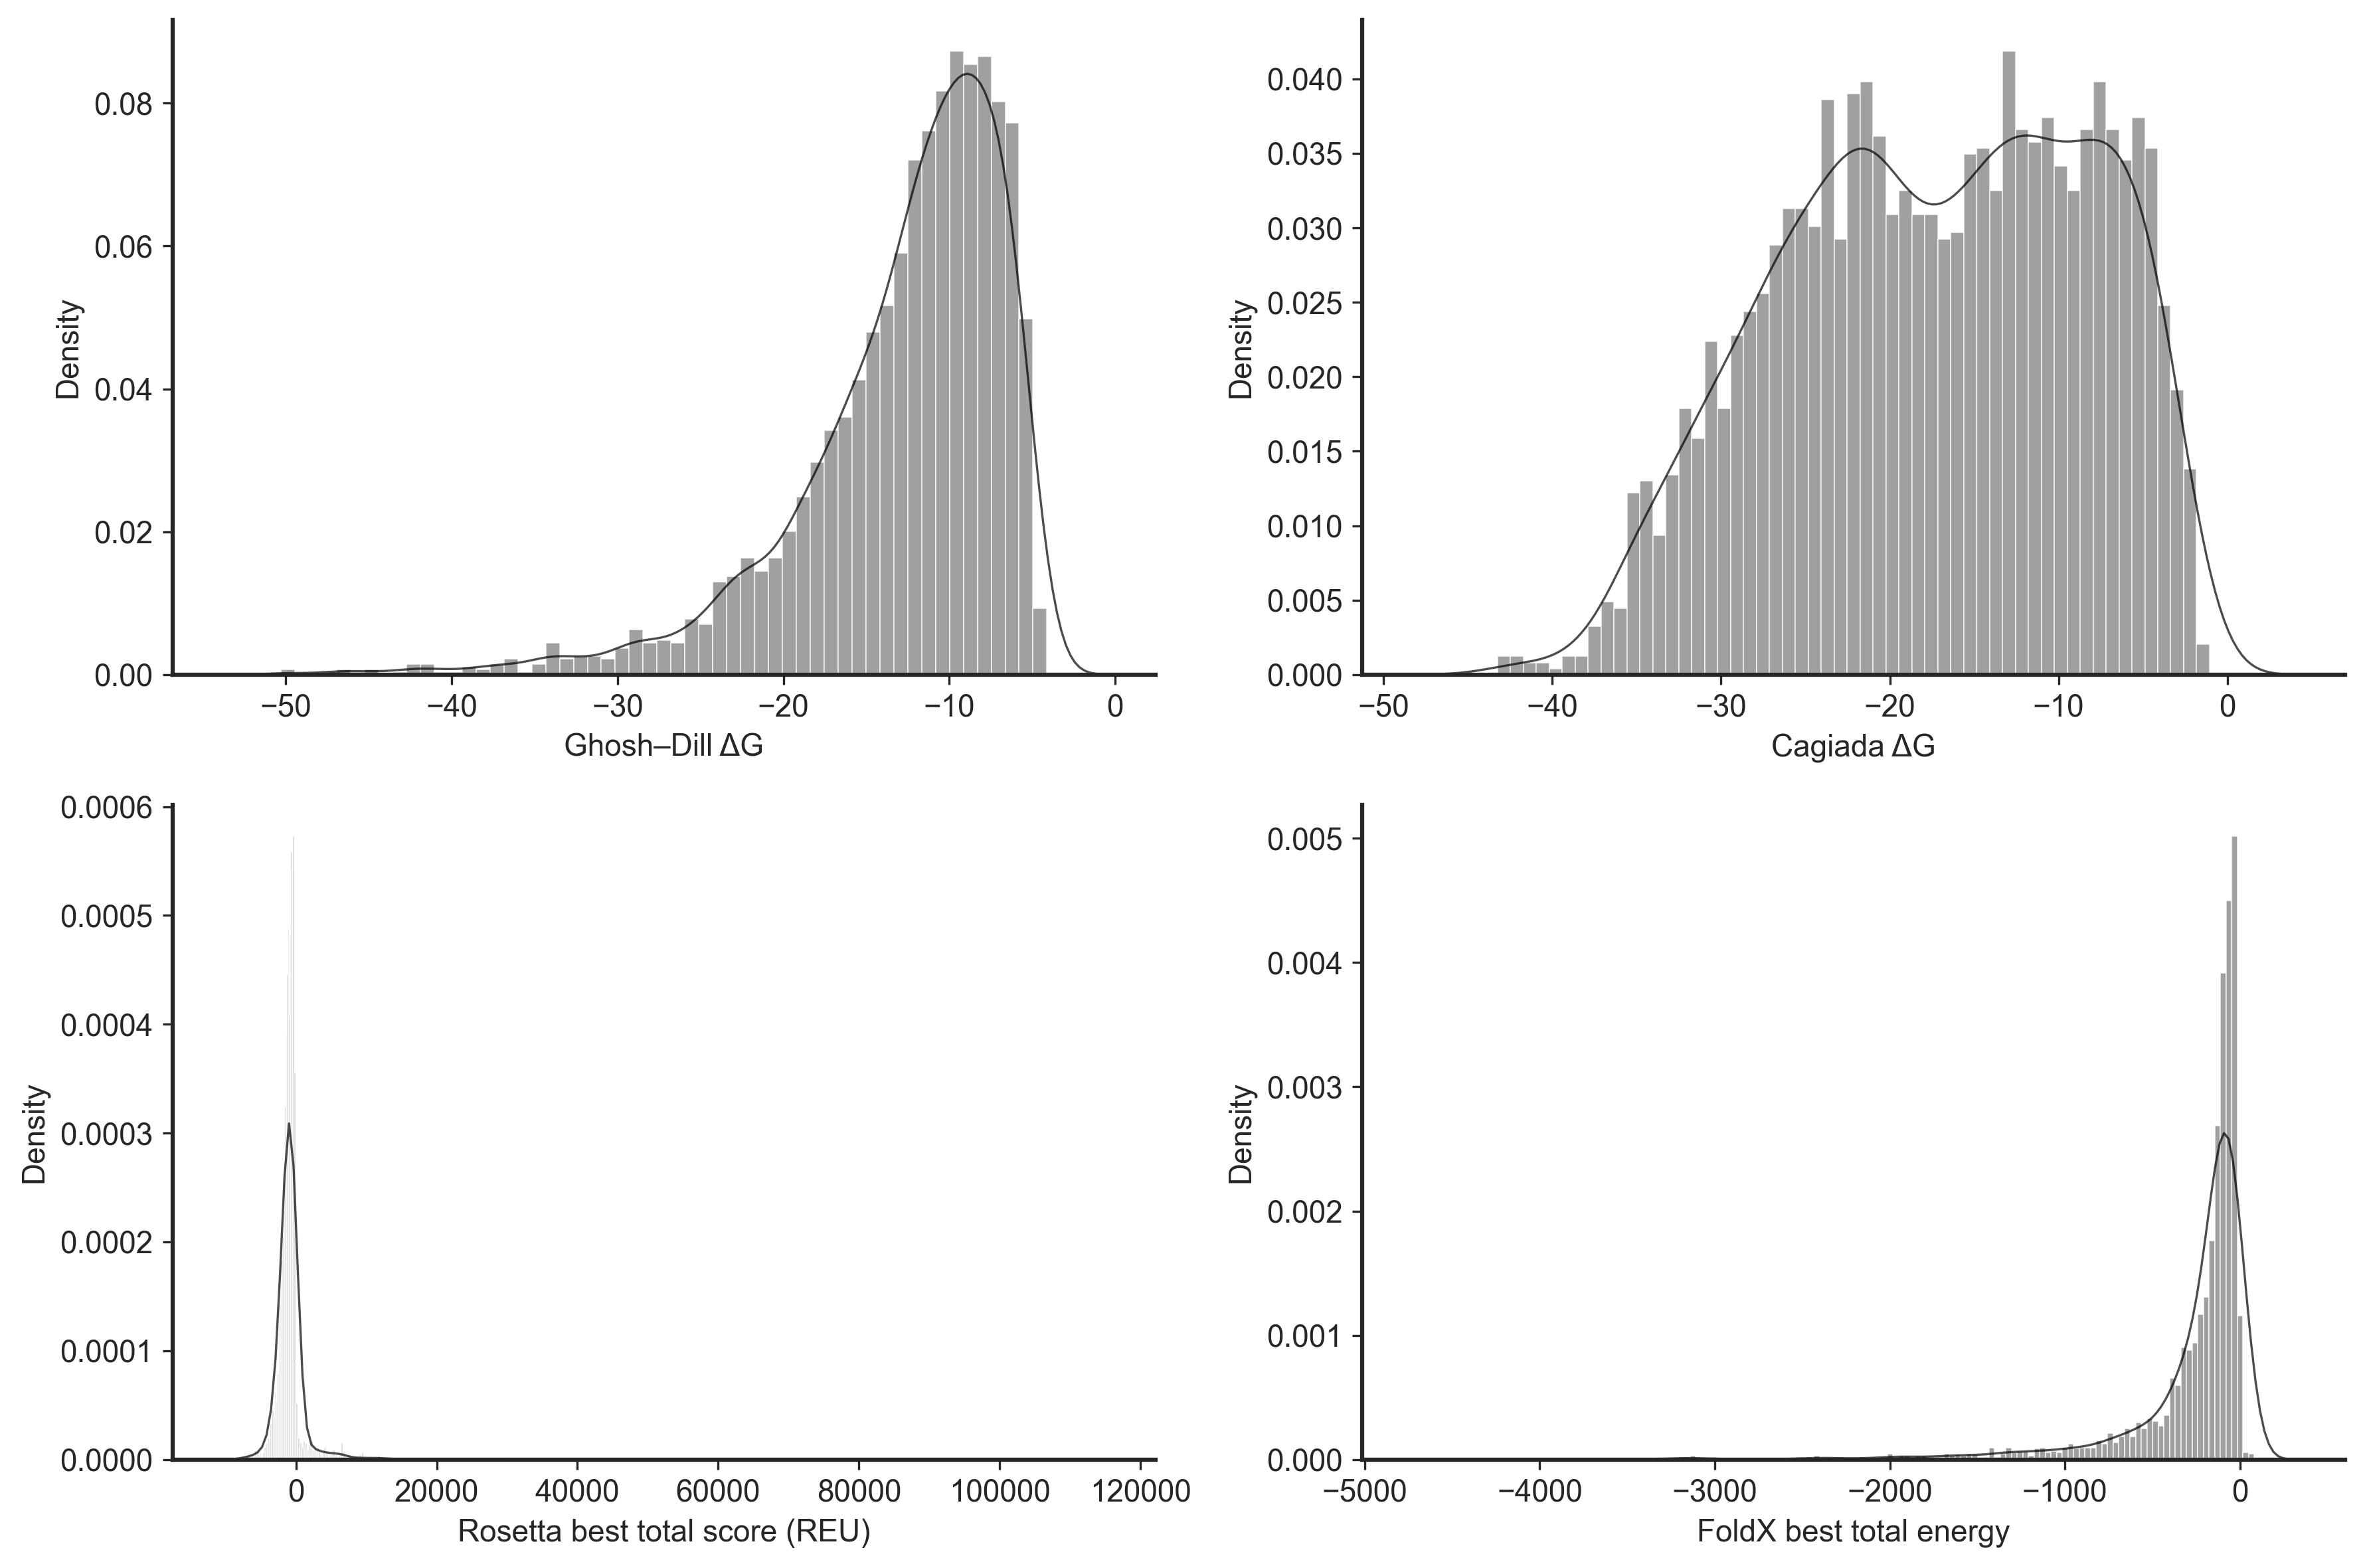

In [13]:
# IMPORT PLOTTING LIBRARIES (add these after your existing imports if not already present)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu  # If needed, but not for this figure

# Set font and style (assuming from previous, add if missing)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
sns.set_style('ticks')
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# PREPARE DATA FOR FIG 3A
# Step 1: Remove proteins with very low pLDDT (<50)
df_3a = selected_columns[selected_columns['mean_plddt'] >= 50].copy()

# Step 2: Remove proteins where DeepTMHMM_class is 'SP', 'TM', or 'SP+TM'
tm_classes_to_remove = ['SP', 'TM', 'SP+TM']
df_3a = df_3a[~df_3a['DeepTMHMM_class'].isin(tm_classes_to_remove)]

# Drop NaNs in stability columns if any
stability_cols = ['Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy']
df_3a = df_3a.dropna(subset=stability_cols)

# Print some stats for confirmation
print(f"Number of proteins after filtering: {df_3a.shape[0]}")

# STEP: CREATE FIGURE 3A - 4 Histograms in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2x2 grid for 4 panels
axes = axes.flatten()  # Flatten for easy indexing

# Plot each histogram
for i, col in enumerate(stability_cols):
    ax = axes[i]

    # Choose binning rule based on column
    if col in ['Rosetta_best_total_score', 'FoldX_best_total_energy']:
        bins_setting = 'fd'   # Freedman–Diaconis rule for wide-range values
    else:
        bins_setting = 55     # Fixed bin count for compact distributions

    # Plot histogram in gray with density normalization
    ax.hist(
        df_3a[col],
        bins=bins_setting,
        color='#888888',
        edgecolor='white',
        alpha=0.8,
        linewidth=0.4,
        density=True
    )
    
    display_names = {
    'Ghosh-Dill-dG': 'Ghosh–Dill ΔG',
    'cagiada-dG': 'Cagiada ΔG',
    'Rosetta_best_total_score': 'Rosetta best total score (REU)',
    'FoldX_best_total_energy': 'FoldX best total energy'
    }

    # Optional KDE overlay for smoothness
    sns.kdeplot(df_3a[col], ax=ax, color='black', lw=0.8, alpha=0.7)

    # Labels
    ax.set_xlabel(display_names[col])
    ax.set_ylabel('Density')


plt.tight_layout()
#plt.savefig('/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE3/3A-stability_distribution.svg', dpi=300)
plt.show()

Number of proteins after filtering: 3208
Yeo–Johnson lambdas:
  Rosetta_best_total_score: 0.846
  FoldX_best_total_energy: 1.410


/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated

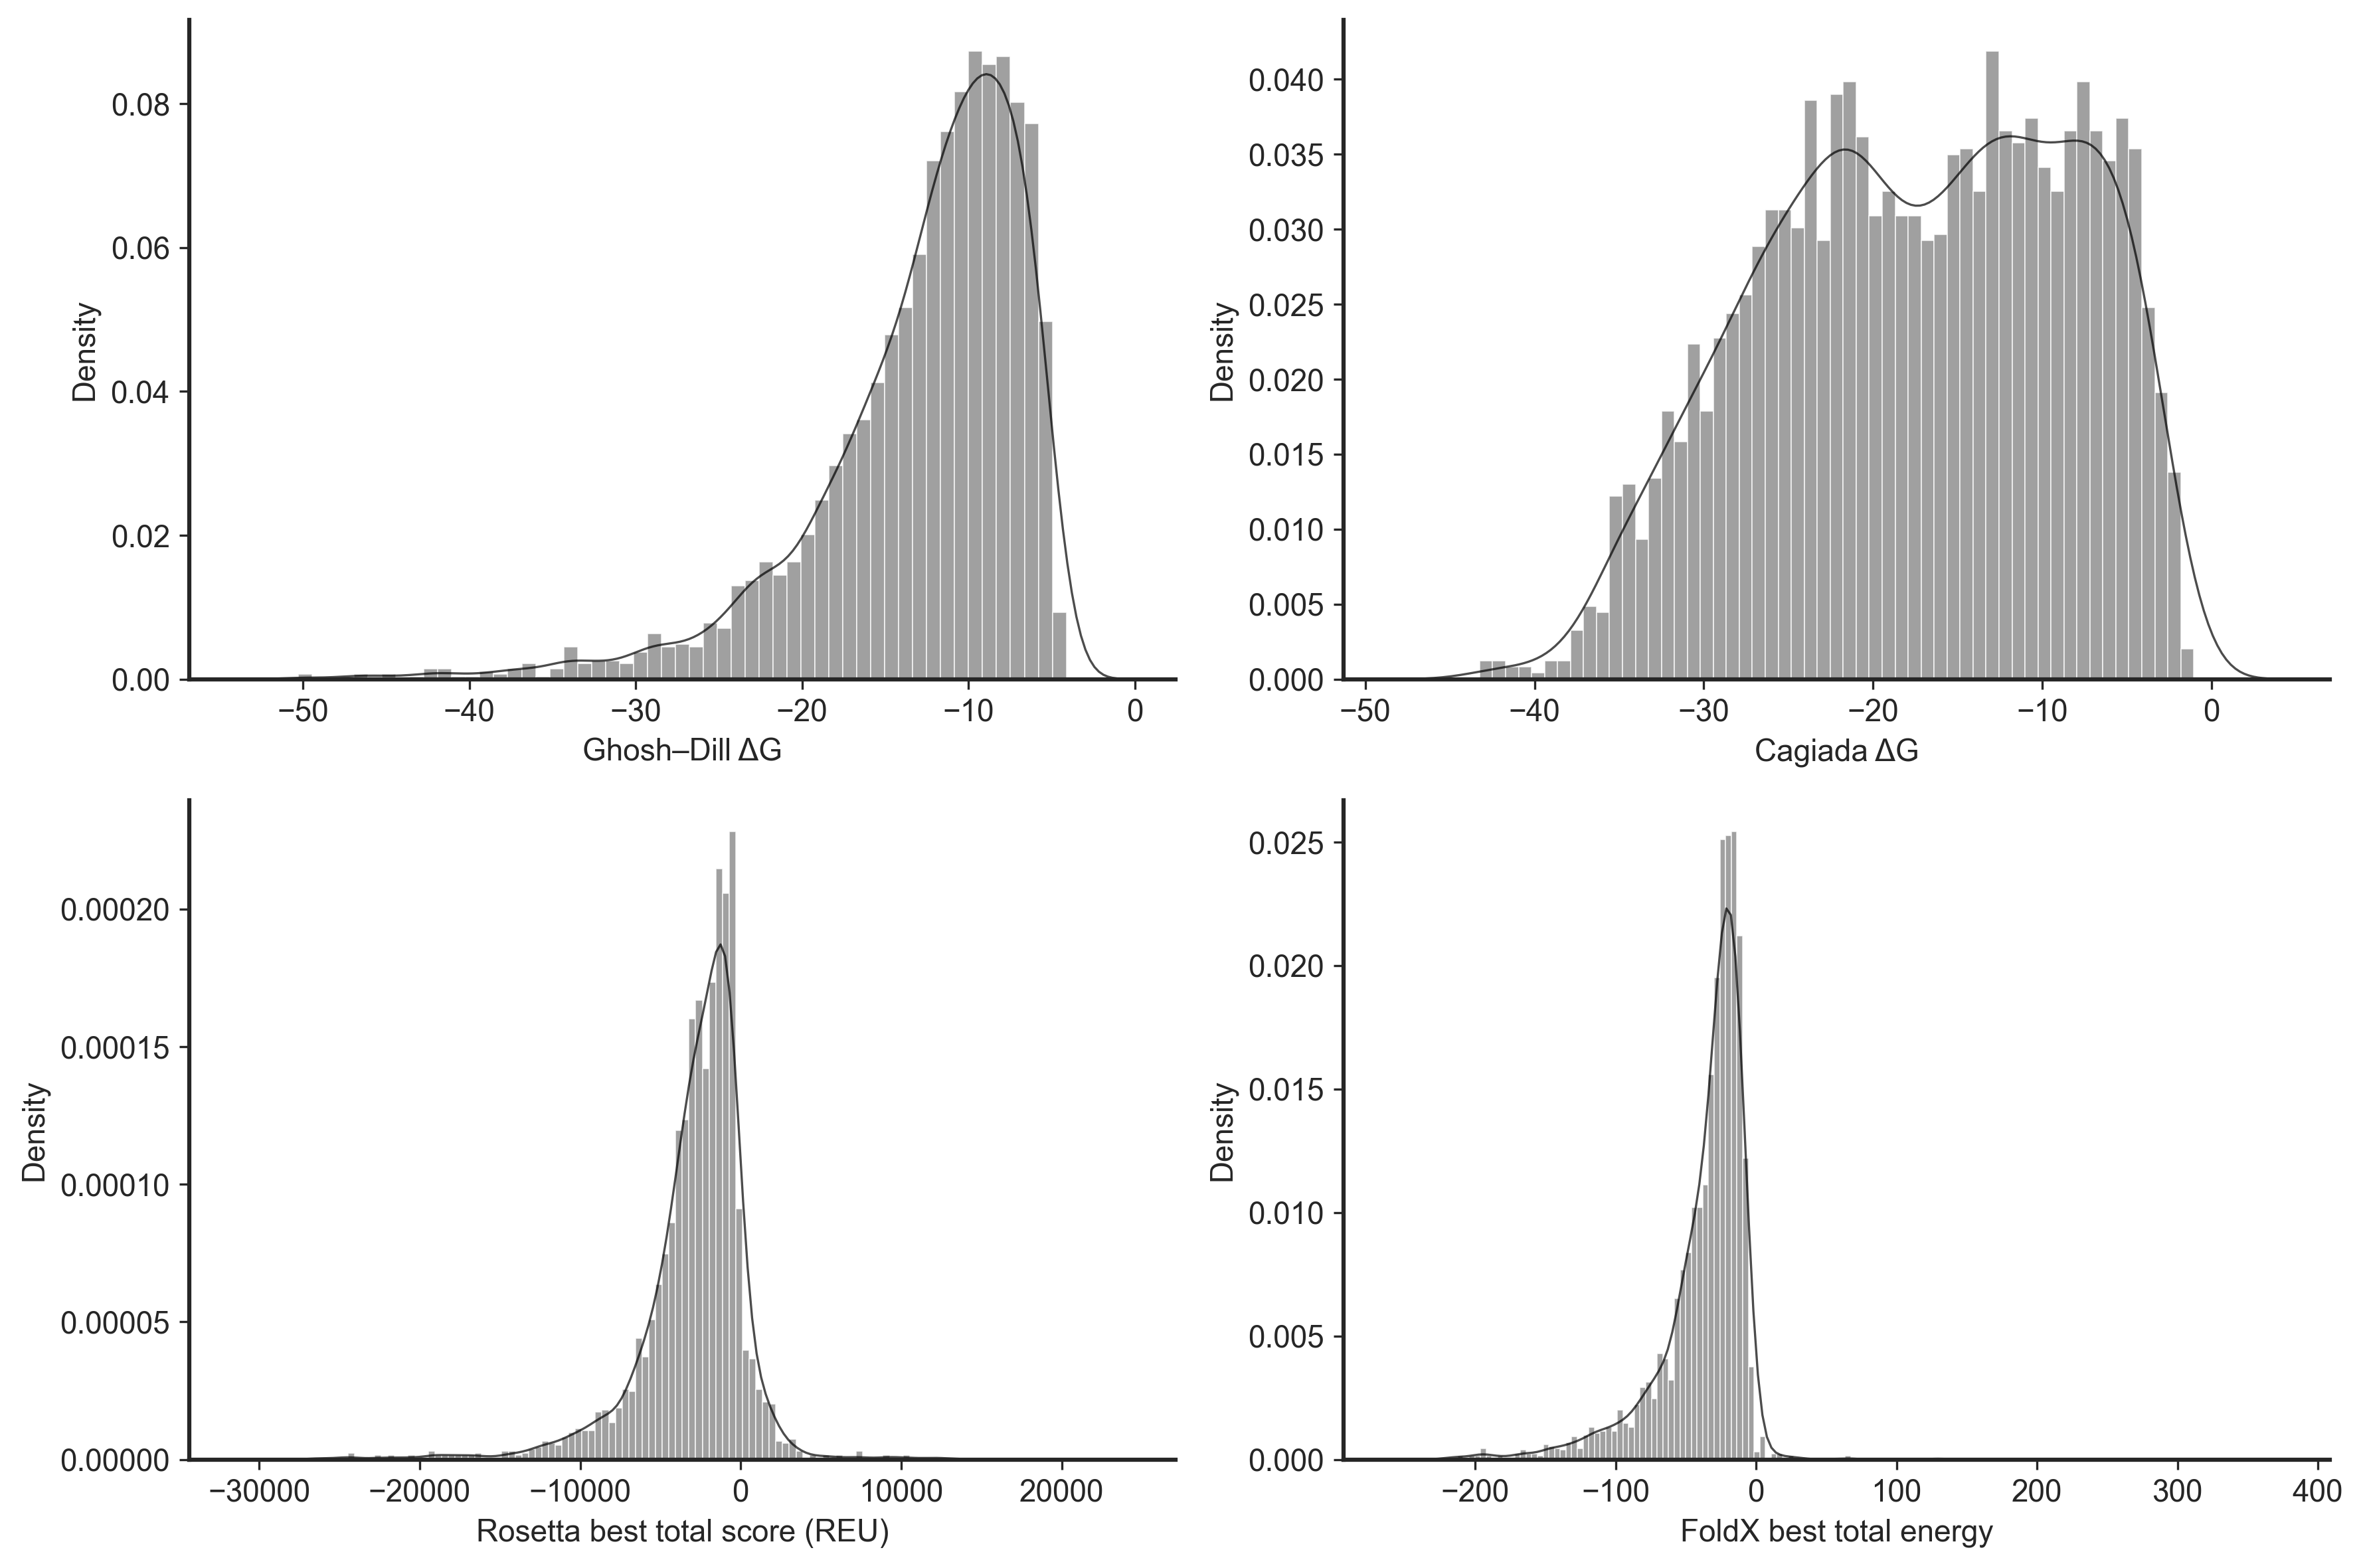

In [12]:
# IMPORT PLOTTING LIBRARIES (add these after your existing imports if not already present)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import PowerTransformer

# Set font and style (assuming from previous, add if missing)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
sns.set_style('ticks')
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# PREPARE DATA FOR FIG 3A
# Step 1: Remove proteins with very low pLDDT (<50)
df_3a = selected_columns[selected_columns['mean_plddt'] >= 50].copy()

# Step 2: Remove proteins where DeepTMHMM_class is 'SP', 'TM', or 'SP+TM'
tm_classes_to_remove = ['SP', 'TM', 'SP+TM']
df_3a = df_3a[~df_3a['DeepTMHMM_class'].isin(tm_classes_to_remove)]

# Drop NaNs in stability columns if any
stability_cols = ['Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy']
df_3a = df_3a.dropna(subset=stability_cols)

# Print some stats for confirmation
print(f"Number of proteins after filtering: {df_3a.shape[0]}")

# Drop NaNs in stability columns if any
stability_cols = ['Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy']
df_3a = df_3a.dropna(subset=stability_cols)

#Power transforms Yeo–Johnson
pt = PowerTransformer(method='yeo-johnson', standardize=False)  # no mean/variance scaling
cols_to_scale = ['Rosetta_best_total_score', 'FoldX_best_total_energy']

df_3a[cols_to_scale] = pt.fit_transform(df_3a[cols_to_scale])

# Optional: print lambdas for reference
print("Yeo–Johnson lambdas:")
for col, lmbda in zip(cols_to_scale, pt.lambdas_):
    print(f"  {col}: {lmbda:.3f}")

# STEP: CREATE FIGURE 3A - 4 Histograms in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2x2 grid for 4 panels
axes = axes.flatten()  # Flatten for easy indexing

# Plot each histogram
for i, col in enumerate(stability_cols):
    ax = axes[i]

    # Choose binning rule based on column
    if col in ['Rosetta_best_total_score', 'FoldX_best_total_energy']:
        bins_setting = 'fd'   # Freedman–Diaconis rule for wide-range values
    else:
        bins_setting = 55     # Fixed bin count for compact distributions

    # Plot histogram in gray with density normalization
    ax.hist(
        df_3a[col],
        bins=bins_setting,
        color='#888888',
        edgecolor='white',
        alpha=0.8,
        linewidth=0.4,
        density=True
    )
    
    display_names = {
    'Ghosh-Dill-dG': 'Ghosh–Dill ΔG',
    'cagiada-dG': 'Cagiada ΔG',
    'Rosetta_best_total_score': 'Rosetta best total score (REU)',
    'FoldX_best_total_energy': 'FoldX best total energy'
    }

    # Optional KDE overlay for smoothness
    sns.kdeplot(df_3a[col], ax=ax, color='black', lw=0.8, alpha=0.7)

    # Labels
    ax.set_xlabel(display_names[col])
    ax.set_ylabel('Density')

plt.tight_layout()
#plt.savefig('/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE3/3A-stability_distribution.svg', dpi=300)
plt.show()

Number of proteins after filtering: 3208


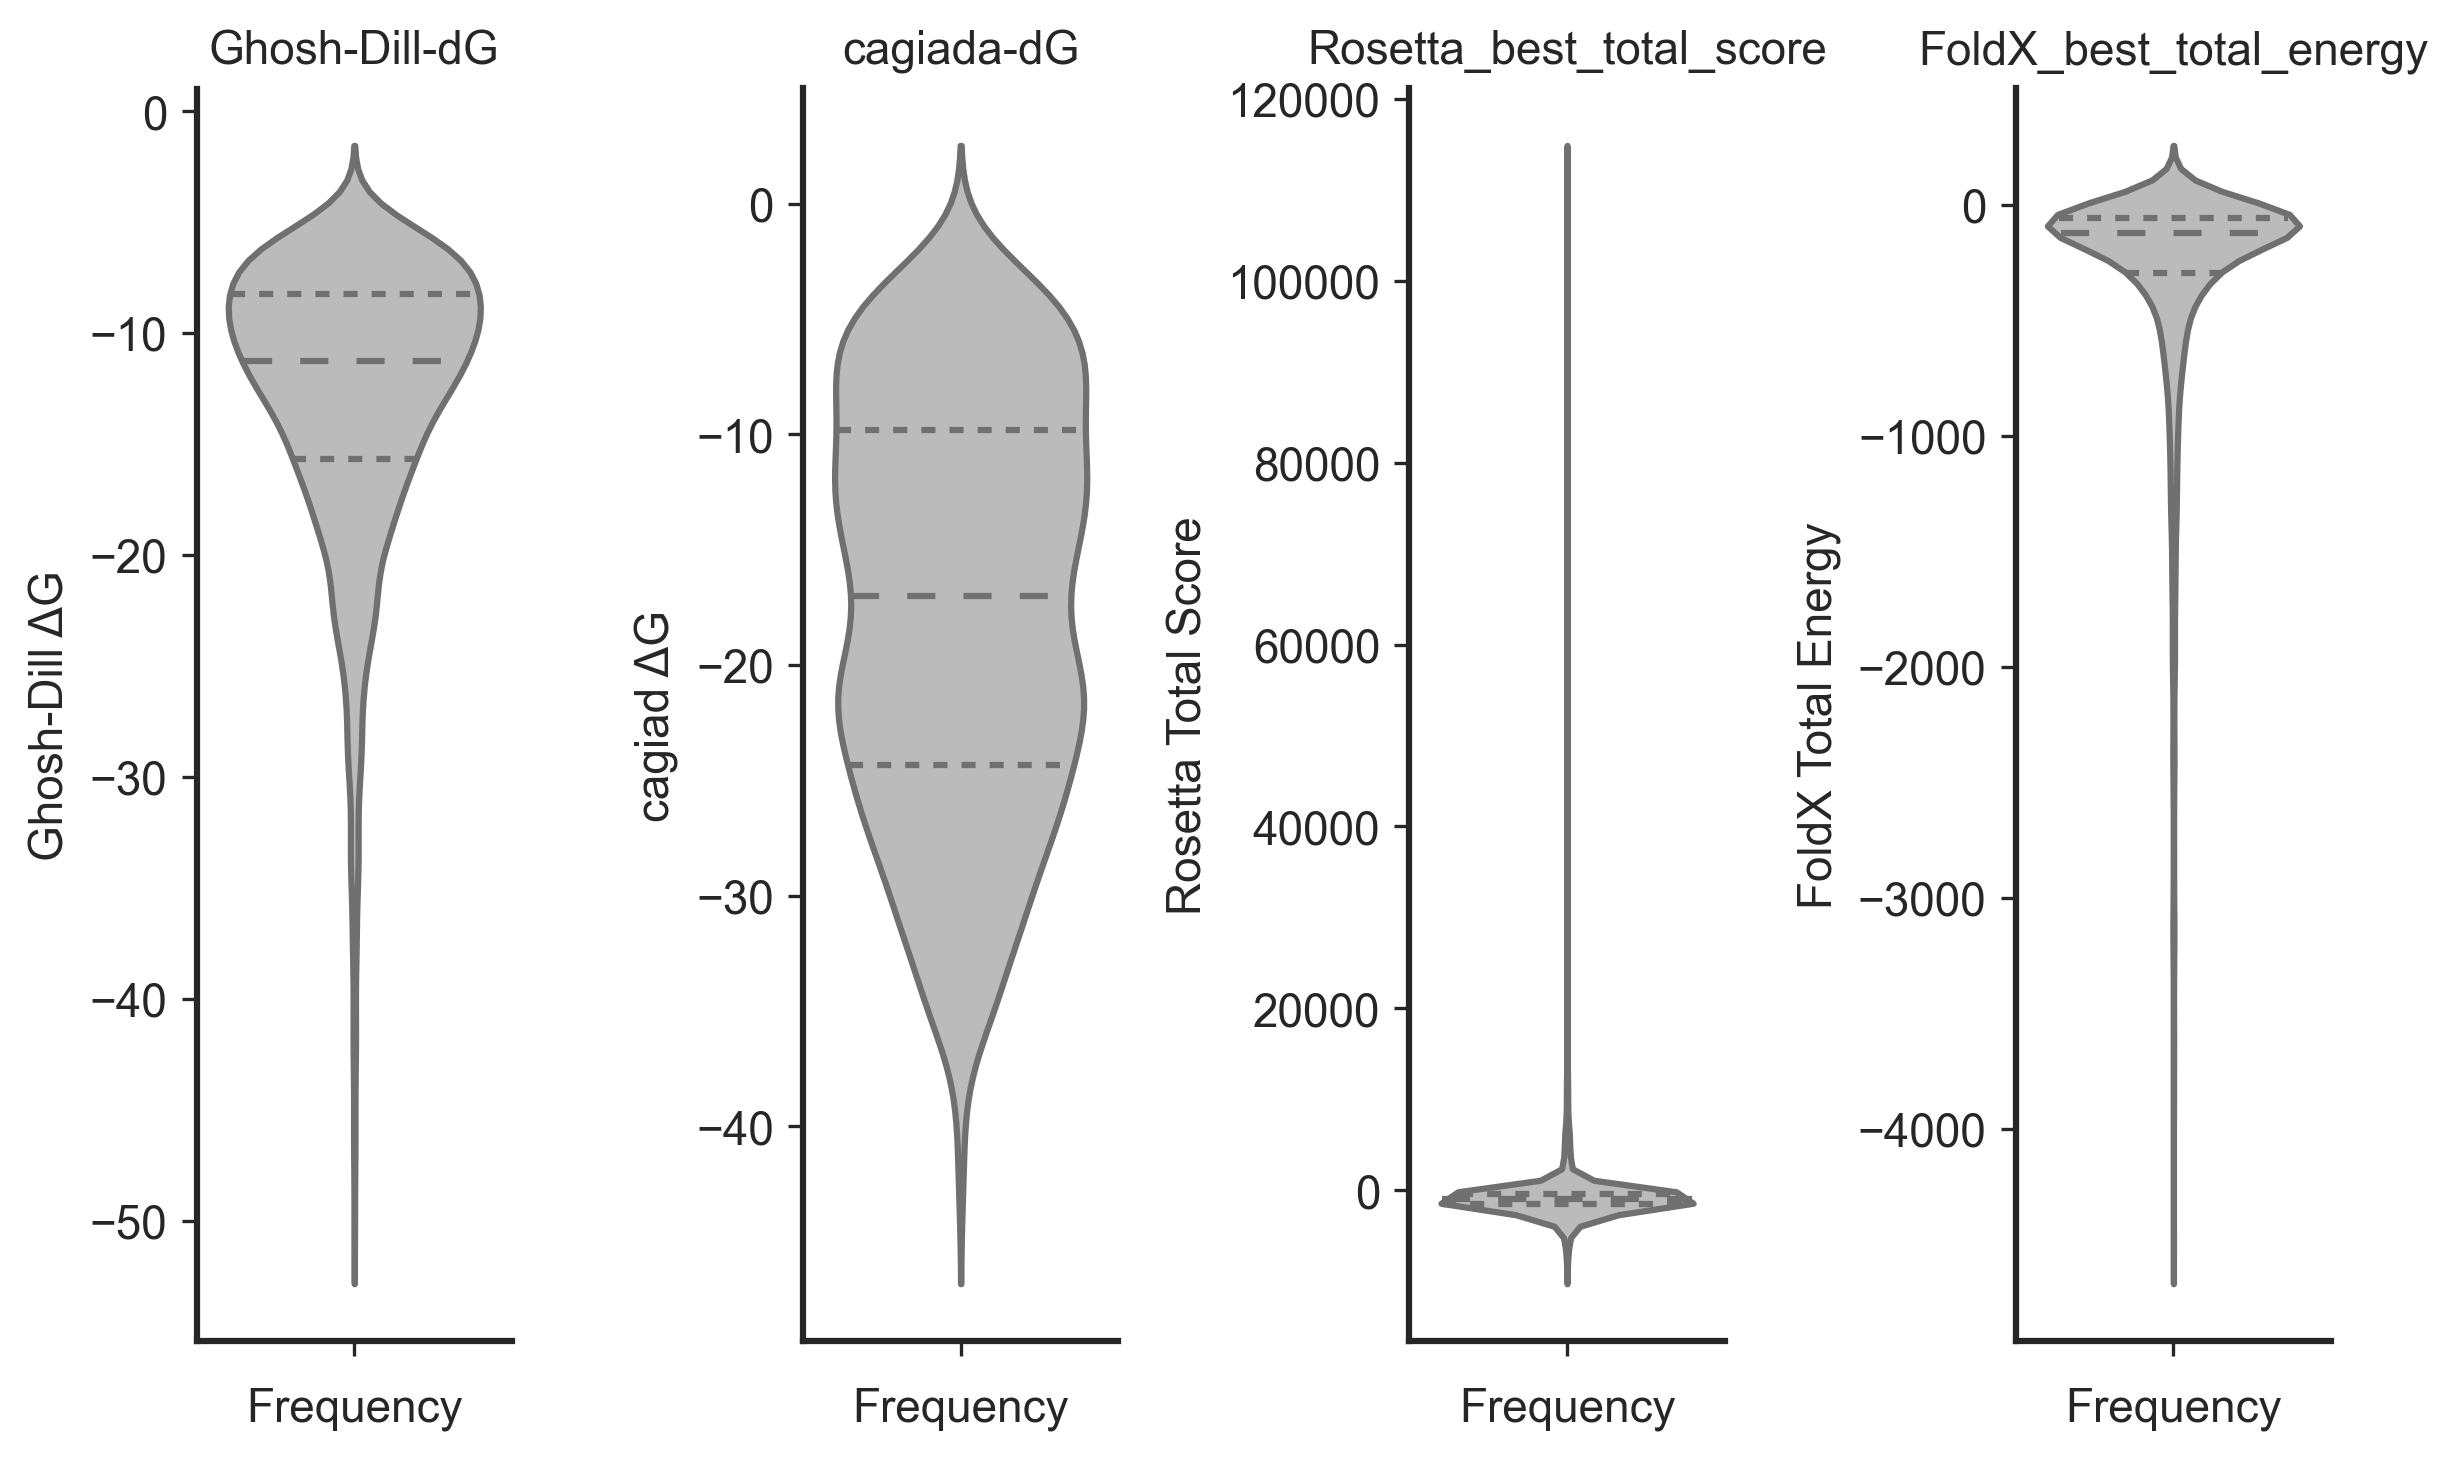

In [8]:
# IMPORT (add if missing)
import seaborn as sns
import matplotlib.pyplot as plt

# Set font and style (assuming from previous, add if missing)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
sns.set_style('ticks')
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# PREPARE DATA FOR FIG 3A
# Step 1: Remove proteins with very low pLDDT (<50)
df_3a = selected_columns[selected_columns['mean_plddt'] >= 50].copy()

# Step 2: Remove proteins where DeepTMHMM_class is 'SP', 'TM', or 'SP+TM'
tm_classes_to_remove = ['SP', 'TM', 'SP+TM']
df_3a = df_3a[~df_3a['DeepTMHMM_class'].isin(tm_classes_to_remove)]

# Drop NaNs in stability columns if any
stability_cols = ['Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy']
df_3a = df_3a.dropna(subset=stability_cols)

# Print some stats for confirmation
print(f"Number of proteins after filtering: {df_3a.shape[0]}")

# Loop through each column and make individual 3x3 plots
for col in stability_cols:
    fig, ax = plt.subplots(figsize=(2, 3))

    sns.violinplot(y=df_3a[col], ax=ax, inner='quartile', color='#BBBBBB', density_norm='width')

    # === UPDATED Y-AXIS LABEL LOGIC (YOUR REQUEST) ===
    if 'Ghosh' in col:
        ax.set_ylabel('Ghosh-Dill ΔG')
    elif 'cagiad' in col or 'CAGIAD' in col:
        ax.set_ylabel('cagiad ΔG')
    elif 'Rosetta' in col:
        ax.set_ylabel('Rosetta Total Score')
    elif 'FoldX' in col:
        ax.set_ylabel('FoldX Total Energy')
    else:
        ax.set_ylabel(col)

    ax.set_xlabel('Frequency')

    # Keep symlog scale if Rosetta or FoldX, without modifying title
    if 'Rosetta' in col or 'FoldX' in col:
        ax.set_yscale('symlog', linthresh=10)

    ax.set_title(f'Distribution of {col}')

    plt.tight_layout()

    #plt.savefig(f'/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE3/3A_{col}_violin.svg', dpi=300)
    plt.close()
    
# === DISPLAY ALL FOUR FIGURES SIDE-BY-SIDE IN NOTEBOOK ===

fig, axes = plt.subplots(1, len(stability_cols), figsize=(8, 5))  # adjust width if needed
axes = axes.flatten()

for i, col in enumerate(stability_cols):
    ax = axes[i]
    sns.violinplot(y=df_3a[col], ax=ax, inner='quartile', color='#BBBBBB', density_norm='width')

    # Same y-axis labeling rules
    if 'Ghosh' in col:
        ax.set_ylabel('Ghosh-Dill ΔG')
    elif 'cagiad' in col or 'CAGIAD' in col:
        ax.set_ylabel('cagiad ΔG')
    elif 'Rosetta' in col:
        ax.set_ylabel('Rosetta Total Score')
    elif 'FoldX' in col:
        ax.set_ylabel('FoldX Total Energy')
    else:
        ax.set_ylabel(col)

    ax.set_xlabel('Frequency')
    
    ax.set_title(f'{col}')

plt.tight_layout()
plt.show()

Yeo–Johnson lambdas:
  Rosetta_best_total_score: 0.846
  FoldX_best_total_energy: 1.410
Number of proteins after filtering: 3208


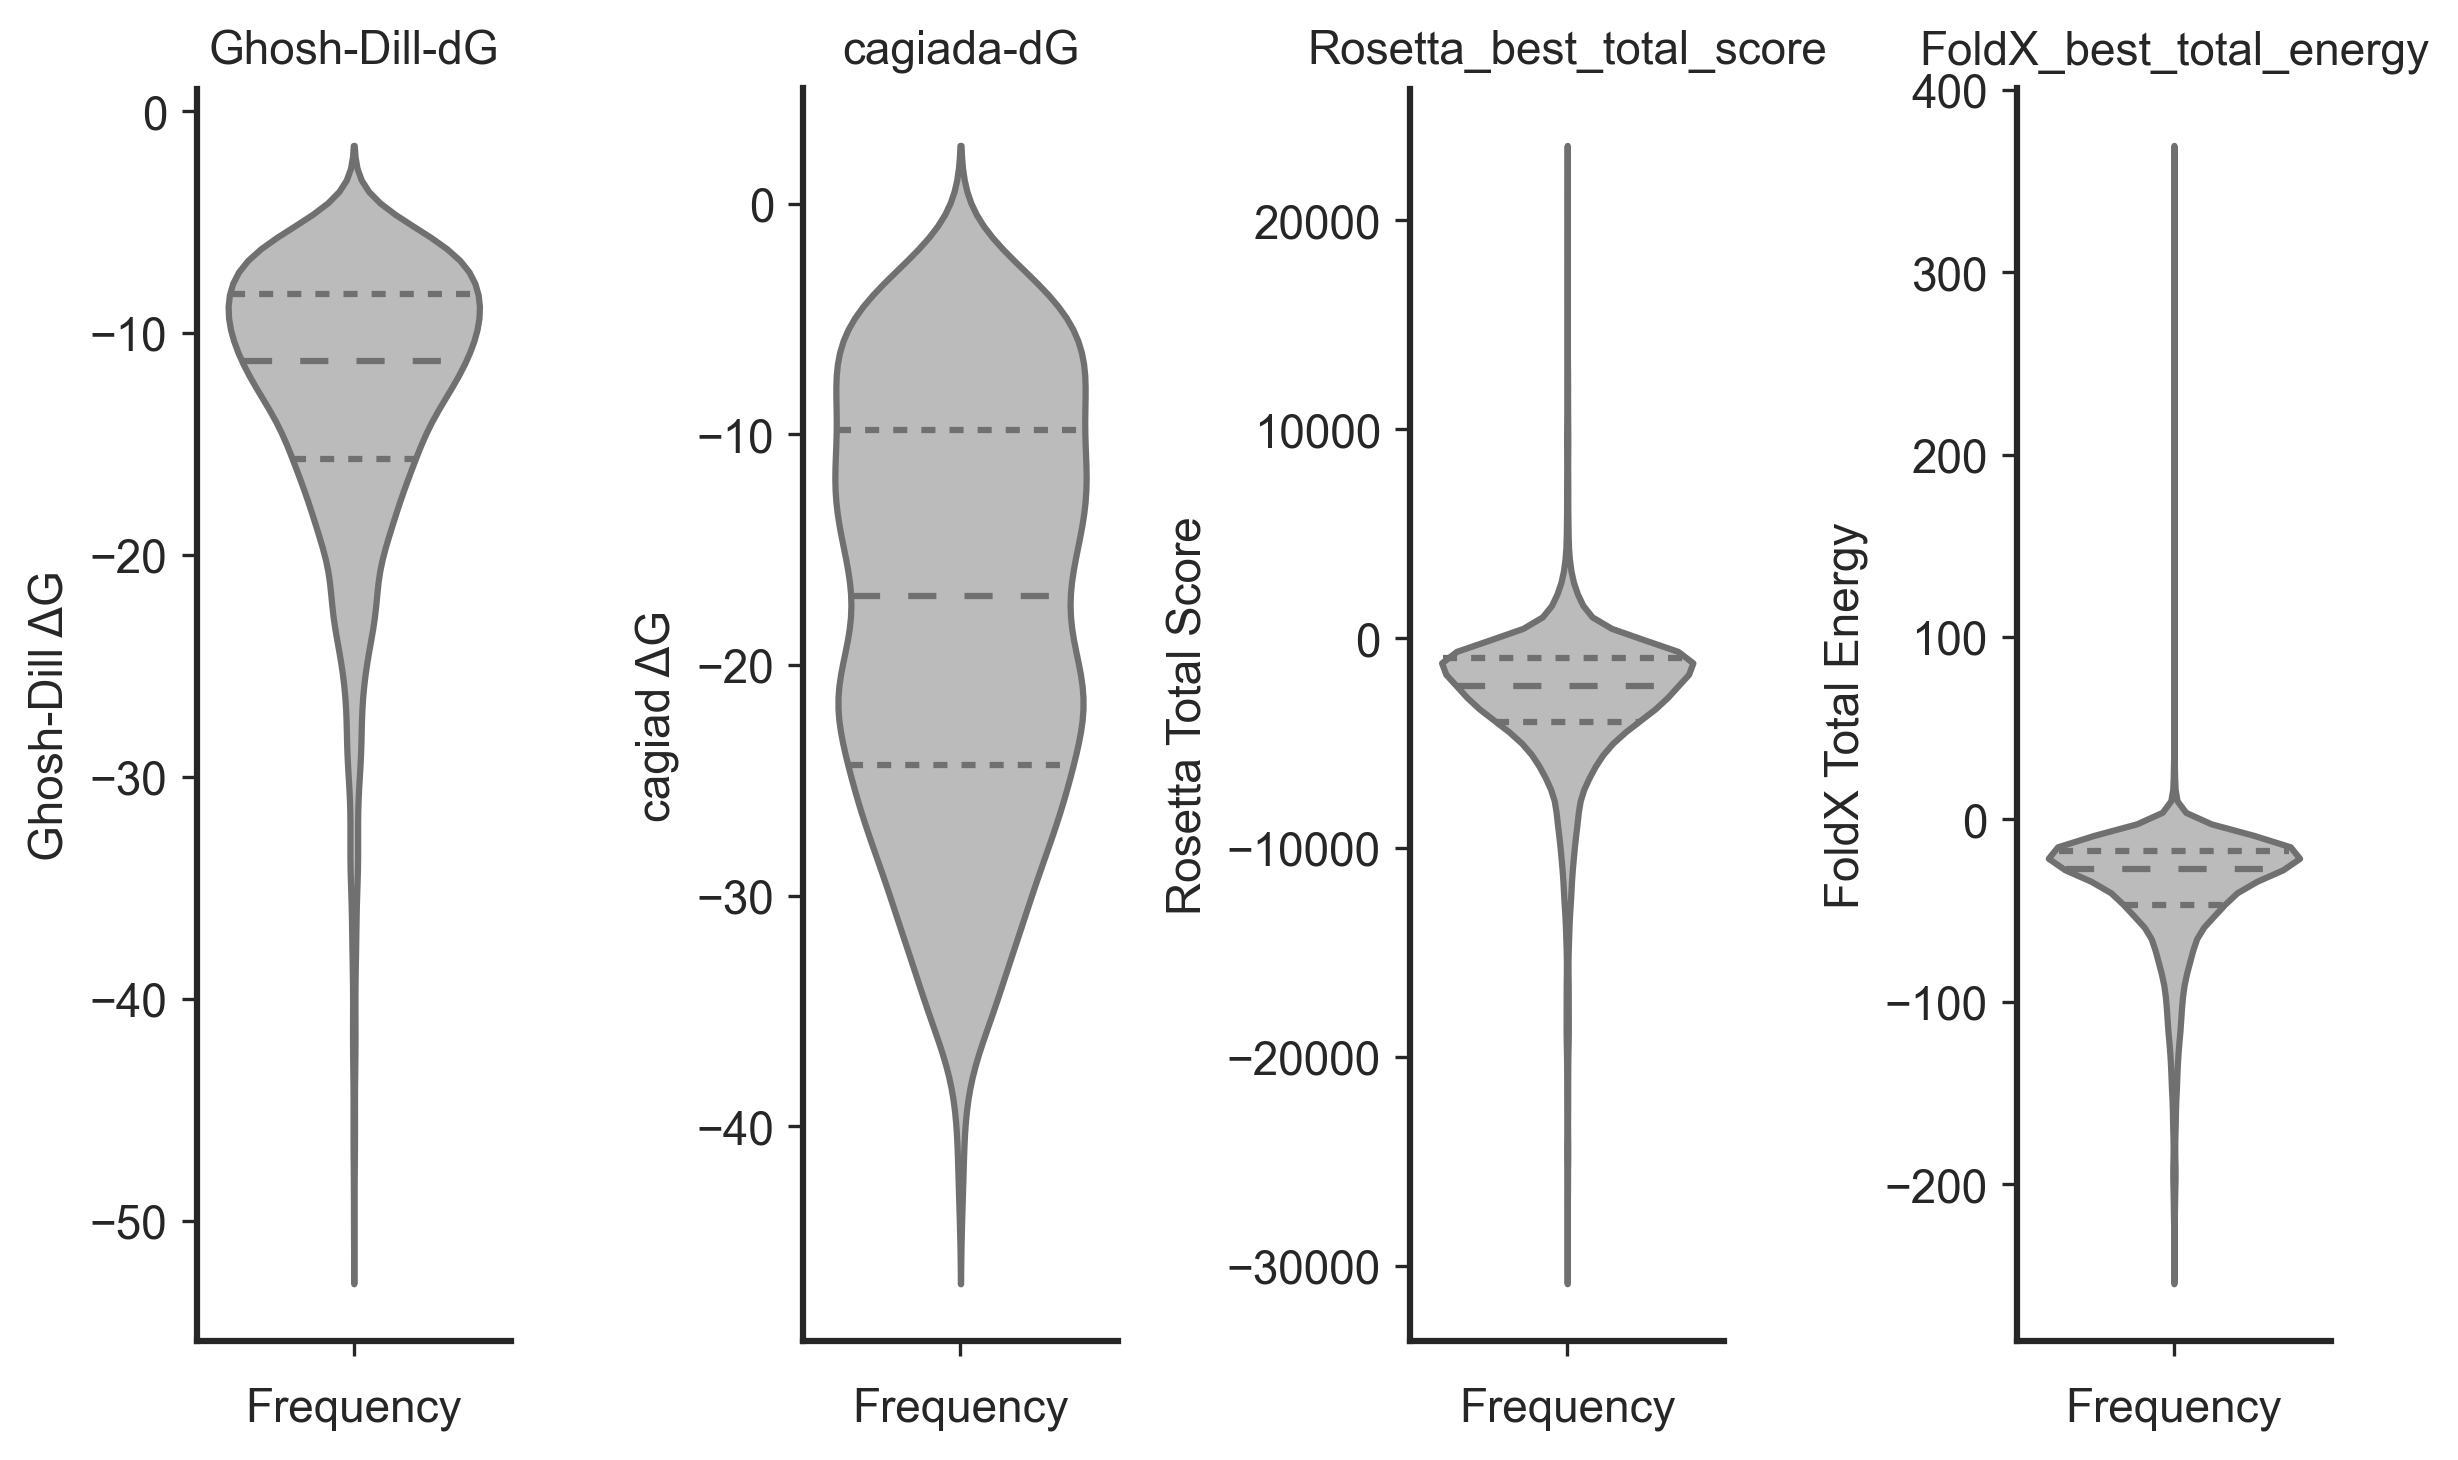

In [9]:
# IMPORT (add if missing)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

# Set font and style (assuming from previous, add if missing)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
sns.set_style('ticks')
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# PREPARE DATA FOR FIG 3A
# Step 1: Remove proteins with very low pLDDT (<50)
df_3a = selected_columns[selected_columns['mean_plddt'] >= 50].copy()

# Step 2: Remove proteins where DeepTMHMM_class is 'SP', 'TM', or 'SP+TM'
tm_classes_to_remove = ['SP', 'TM', 'SP+TM']
df_3a = df_3a[~df_3a['DeepTMHMM_class'].isin(tm_classes_to_remove)]

# Drop NaNs in stability columns if any
stability_cols = ['Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy']
df_3a = df_3a.dropna(subset=stability_cols)

# --- Apply Yeo–Johnson scaling to Rosetta and FoldX ---
pt = PowerTransformer(method='yeo-johnson', standardize=False)
cols_to_scale = ['Rosetta_best_total_score', 'FoldX_best_total_energy']
df_3a[cols_to_scale] = pt.fit_transform(df_3a[cols_to_scale])

print("Yeo–Johnson lambdas:")
for col, lmbda in zip(cols_to_scale, pt.lambdas_):
    print(f"  {col}: {lmbda:.3f}")

# Print stats
print(f"Number of proteins after filtering: {df_3a.shape[0]}")

# --- INDIVIDUAL VIOLIN PLOTS ---
for col in stability_cols:
    fig, ax = plt.subplots(figsize=(2, 3))
    sns.violinplot(y=df_3a[col], ax=ax, inner='quartile', color='#BBBBBB', density_norm='width')

    # Label
    if 'Ghosh' in col:
        ax.set_ylabel('Ghosh-Dill ΔG')
    elif 'cagiad' in col or 'CAGIAD' in col:
        ax.set_ylabel('cagiad ΔG')
    elif 'Rosetta' in col:
        ax.set_ylabel('Rosetta Total Score')
    elif 'FoldX' in col:
        ax.set_ylabel('FoldX Total Energy')
    else:
        ax.set_ylabel(col)

    ax.set_xlabel('Frequency')

    ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    #plt.savefig(f'/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE3/3A_{col}_violin.svg', dpi=300)
    plt.close()

# --- SIDE-BY-SIDE PANEL ---
fig, axes = plt.subplots(1, len(stability_cols), figsize=(8, 5))
axes = axes.flatten()

for i, col in enumerate(stability_cols):
    ax = axes[i]
    sns.violinplot(y=df_3a[col], ax=ax, inner='quartile', color='#BBBBBB', density_norm='width')

    if 'Ghosh' in col:
        ax.set_ylabel('Ghosh-Dill ΔG')
    elif 'cagiad' in col or 'CAGIAD' in col:
        ax.set_ylabel('cagiad ΔG')
    elif 'Rosetta' in col:
        ax.set_ylabel('Rosetta Total Score')
    elif 'FoldX' in col:
        ax.set_ylabel('FoldX Total Energy')
    else:
        ax.set_ylabel(col)

    ax.set_xlabel('Frequency')
    ax.set_title(f'{col}')

plt.tight_layout()
plt.show()



=== Percentage Differences for IPMS Degree Centrality ===
Hubs are -8.20% greater than Non-hubs (medians: 45.63 vs 49.71)

=== Mann–Whitney U Tests for IPMS Degree Centrality ===
Hubs vs Non-hubs: U=88257.50, p=6.727e-33, n1=266, n2=1243

=== Kolmogorov-Smirnov Tests for IPMS Degree Centrality ===
Hubs vs Non-hubs: KS=0.37, p=1.296e-27, n1=266, n2=1243

=== Percentage Differences for Y2H Degree Centrality ===
Hubs are 0.06% greater than Non-hubs (medians: 49.87 vs 49.84)

=== Mann–Whitney U Tests for Y2H Degree Centrality ===
Hubs vs Non-hubs: U=19959.50, p=0.7798, n1=71, n2=551

=== Kolmogorov-Smirnov Tests for Y2H Degree Centrality ===
Hubs vs Non-hubs: KS=0.09, p=0.7034, n1=71, n2=551


/tmp/ipykernel_4020758/355458663.py:75: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_sub


=== Percentage Differences for IPMS Betweenness Centrality ===
Hubs are -1.03% greater than Non-hubs (medians: 48.79 vs 49.30)

=== Mann–Whitney U Tests for IPMS Betweenness Centrality ===
Hubs vs Non-hubs: U=135043.00, p=0.03924, n1=231, n2=1278

=== Kolmogorov-Smirnov Tests for IPMS Betweenness Centrality ===
Hubs vs Non-hubs: KS=0.09, p=0.06261, n1=231, n2=1278

=== Percentage Differences for Y2H Betweenness Centrality ===
Hubs are -0.51% greater than Non-hubs (medians: 49.61 vs 49.86)

=== Mann–Whitney U Tests for Y2H Betweenness Centrality ===
Hubs vs Non-hubs: U=14234.50, p=0.6372, n1=52, n2=570

=== Kolmogorov-Smirnov Tests for Y2H Betweenness Centrality ===
Hubs vs Non-hubs: KS=0.12, p=0.502, n1=52, n2=570


/tmp/ipykernel_4020758/355458663.py:75: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_sub

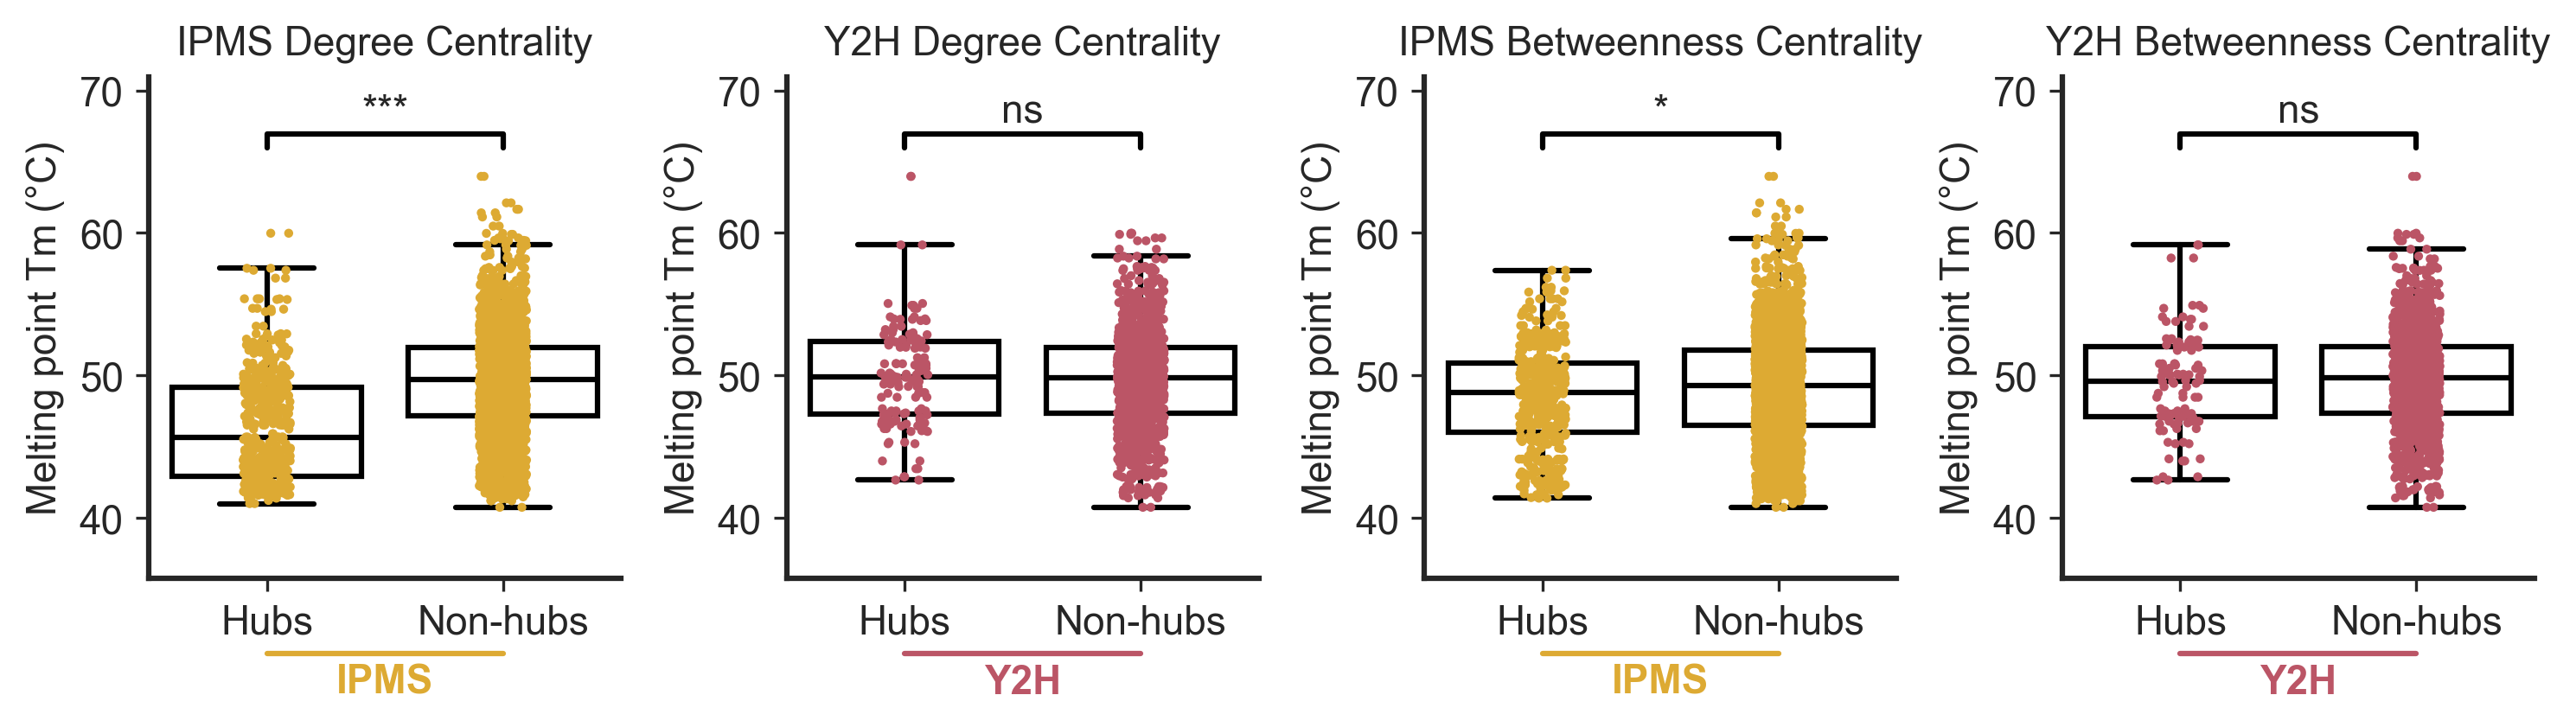

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ks_2samp
import os
# Set global font settings for publication quality
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
def test_hub_melting_point_boxplot(selected_columns, col, network, save_dir, metric_name, ax=None, save=True, show=True, print_stats=True):
    # === Define color and label based on network ===
    if network == 'IPMS':
        color = '#DDAA33'
        network_label = 'IPMS'
    elif network == 'Y2H':
        color = '#BB5566'
        network_label = 'Y2H'
    else:
        raise ValueError("Network must be 'IPMS' or 'Y2H'")

    # Filter for proteins with 'meltome-fit-R2' > 0.9
    selected_columns = selected_columns[selected_columns['meltome-fit-R2'] >= 0.9]
    # === Define hub vs non-hub groups ===
    hubs = selected_columns[selected_columns[col] >= 90]['meltome-melting-point'].dropna()
    nonhubs = selected_columns[selected_columns[col] < 90]['meltome-melting-point'].dropna()

    # === Combine into a single dataframe ===
    data = pd.DataFrame({
        'Group': (['Hubs'] * len(hubs)) +
                 (['Non-hubs'] * len(nonhubs)),
        'melting_point': np.concatenate([hubs, nonhubs])
    })
   
    # === Mann–Whitney tests ===
    if print_stats:
        print(f"\n=== Percentage Differences for {network_label} {metric_name} ===")
        hubs_median = np.median(hubs)
        nonhubs_median = np.median(nonhubs)
        percentage = ((hubs_median - nonhubs_median) / nonhubs_median) * 100 if nonhubs_median != 0 else 0 #CALCULATIONS FOR PERCENTAGE
        print(f"Hubs are {percentage:.2f}% greater than Non-hubs (medians: {hubs_median:.2f} vs {nonhubs_median:.2f})")

        print(f"\n=== Mann–Whitney U Tests for {network_label} {metric_name} ===")
        tests = [
            ('Hubs vs Non-hubs', hubs, nonhubs)
        ]
        p_values = []
        for name, g1, g2 in tests:
            stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
            print(f"{name}: U={stat:.2f}, p={p:.4g}, n1={len(g1)}, n2={len(g2)}")
            p_values.append(p)

        print(f"\n=== Kolmogorov-Smirnov Tests for {network_label} {metric_name} ===")
        for name, g1, g2 in tests:
            stat, p = ks_2samp(g1, g2)
            print(f"{name}: KS={stat:.2f}, p={p:.4g}, n1={len(g1)}, n2={len(g2)}")
    else:
        # Still compute p_values even if not printing
        tests = [
            (hubs, nonhubs)
        ]
        p_values = [mannwhitneyu(g1, g2, alternative='two-sided')[1] for g1, g2 in tests]
   
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
   
    # === Plot: Boxplot + swarm overlay ===
    sns.stripplot(
        data=data,
        x='Group',
        y='melting_point', # Use original mean_molecules_per_cell data
        palette={'Hubs': color, 'Non-hubs': color},
        size=2.5,
        alpha=1.0,
        jitter=True,
        ax=ax
    )
    sns.boxplot(
        data=data,
        x='Group',
        y='melting_point', # Use original mean_molecules_per_cell data
        palette={'Hubs': color, 'Non-hubs': color},
        showcaps=True,
        showfliers=False,
        fliersize=2,
        linewidth=1.5,
        boxprops={'edgecolor': 'black'},
        whiskerprops={'color': 'black', 'linewidth': 1.5},
        capprops={'color': 'black', 'linewidth': 1.5},
        medianprops={'color': 'black', 'linewidth': 1.5},
        width=0.8,
        ax=ax
    )
    for i, artist in enumerate(ax.patches):
        artist.set_facecolor('none')
        artist.set_edgecolor('black')
    sns.stripplot(
        data=data,
        x='Group',
        y='melting_point',
        palette={'Hubs': color, 'Non-hubs': color},
        size=2.5,
        alpha=1.0,
        jitter=True,
        ax=ax
    )
   
    # === Set y-axis to logarithmic scale ===
    #ax.set_yscale('log')
    ax.set_ylabel('Melting point Tm (°C)')
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Hubs', 'Non-hubs'], rotation=0, ha='center')
   
    # === Add significance bars ===
    def add_significance_bar(x1, x2, y, p_value, ax, force_ns=False):
        height = y
        v_offset = 1  # Fixed vertical length of the bar arms (adjust if needed, e.g., 2-5)
        text_offset = 0.22  # Fixed gap above bar for stars text (adjust if needed, e.g., 1-3)
        bar_top = height + v_offset
        ax.plot([x1, x1, x2, x2], [height, bar_top, bar_top, height], lw=1.5, c='black')
        stars = 'ns' if force_ns or p_value >= 0.05 else '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
        ax.text((x1 + x2) * 0.5, bar_top + text_offset, stars, ha='center', va='bottom', fontfamily='Arial', fontsize=11)
   
    max_y = data['melting_point'].max()
    y_start = max_y + 2  # Start bars just above max data (adjust 5 if needed, e.g., 2-10)
    bar_spacing = 2  # Fixed stacking gap between bars (adjust if needed, e.g., 5-15)
    comparisons = [(0, 1, 0)]
    for idx, (x1, x2, test_idx) in enumerate(comparisons):
        force_ns = False  # Removed forcing for Y2H; let p-value decide (change to True if you want ns forced)
        add_significance_bar(x1, x2, y_start + idx * bar_spacing, p_values[test_idx], ax, force_ns=force_ns)
    min_y = data['melting_point'].min()
    highest_y = y_start + (len(comparisons) - 1) * bar_spacing + 5  # Buffer above top bar
    ax.set_ylim(min_y - 5, highest_y)  # Adjust buffers (-5 and +15) based on your data range
   
    # Add horizontal lines under MS and Y2H pairs
    ax.plot([0, 1], [-0.15, -0.15], color=color, lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.text(0.5, -0.17, network_label, ha='center', va='top', fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(), color=color, fontweight='bold')
   
    ax.set_title(f'{network_label} {metric_name}')
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
   
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f'melting_point-{network_label.lower()}-{metric_name.lower().replace(" ", "-")}.svg')
        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')
   
    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())
# === Example: loop over both centrality metrics ===
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE3"
plots = [
    ('MS_degree_centrality_percentile', 'IPMS', 'Degree Centrality'),
    ('Y2H_degree_centrality_percentile', 'Y2H', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'IPMS', 'Betweenness Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Y2H', 'Betweenness Centrality')
]
# Save individual plots (with stats printed)
for col, network, metric_name in plots:
    test_hub_melting_point_boxplot(filtered_df, col, network, save_dir, metric_name, ax=None, save=True, show=False, print_stats=True)
# Display adjacent plots (no additional prints)
fig, axs = plt.subplots(1, 4, figsize=(10, 3))
for i, (col, network, metric_name) in enumerate(plots):
    test_hub_melting_point_boxplot(filtered_df, col, network, save_dir, metric_name, ax=axs[i], save=False, show=False, print_stats=False)
plt.tight_layout()
plt.show()


=== Percentage Differences for IPMS Degree Centrality - Ghosh-Dill ΔG ===
Hubs IPMS are -28.44% greater than Non-hubs IPMS (medians: -8.27 vs -11.56)

=== Mann–Whitney U Tests for IPMS Degree Centrality - Ghosh-Dill ΔG ===
Hubs vs Non-hubs: U=692059.50, p=6.064e-22, n1=374, n2=2834

=== Kolmogorov-Smirnov Tests for IPMS Degree Centrality - Ghosh-Dill ΔG ===
Hubs vs Non-hubs: KS=0.29, p=9.658e-25, n1=374, n2=2834


/tmp/ipykernel_4020758/1648553442.py:61: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su


=== Percentage Differences for Y2H Degree Centrality - Ghosh-Dill ΔG ===
Hubs Y2H are 6.83% greater than Non-hubs Y2H (medians: -11.33 vs -10.60)

=== Mann–Whitney U Tests for Y2H Degree Centrality - Ghosh-Dill ΔG ===
Hubs vs Non-hubs: U=79746.00, p=0.1132, n1=150, n2=1155

=== Kolmogorov-Smirnov Tests for Y2H Degree Centrality - Ghosh-Dill ΔG ===
Hubs vs Non-hubs: KS=0.11, p=0.0685, n1=150, n2=1155


/tmp/ipykernel_4020758/1648553442.py:61: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su


=== Percentage Differences for IPMS Betweenness Centrality - Ghosh-Dill ΔG ===
Hubs IPMS are -1.55% greater than Non-hubs IPMS (medians: -11.09 vs -11.27)

=== Mann–Whitney U Tests for IPMS Betweenness Centrality - Ghosh-Dill ΔG ===
Hubs vs Non-hubs: U=473186.50, p=0.731, n1=333, n2=2875

=== Kolmogorov-Smirnov Tests for IPMS Betweenness Centrality - Ghosh-Dill ΔG ===
Hubs vs Non-hubs: KS=0.04, p=0.7897, n1=333, n2=2875


...

/tmp/ipykernel_4020758/1648553442.py:61: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su


=== Percentage Differences for IPMS Betweenness Centrality - Rosetta Best Total Score ===
Hubs IPMS are 20.07% greater than Non-hubs IPMS (medians: -1071.48 vs -892.34)

=== Mann–Whitney U Tests for IPMS Betweenness Centrality - Rosetta Best Total Score ===
Hubs vs Non-hubs: U=427541.00, p=0.001391, n1=333, n2=2875

=== Kolmogorov-Smirnov Tests for IPMS Betweenness Centrality - Rosetta Best Total Score ===
Hubs vs Non-hubs: KS=0.09, p=0.01003, n1=333, n2=2875


/tmp/ipykernel_4020758/1648553442.py:61: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su


=== Percentage Differences for Y2H Betweenness Centrality - Rosetta Best Total Score ===
Hubs Y2H are -3.25% greater than Non-hubs Y2H (medians: -819.26 vs -846.75)

=== Mann–Whitney U Tests for Y2H Betweenness Centrality - Rosetta Best Total Score ===
Hubs vs Non-hubs: U=75262.00, p=0.6895, n1=131, n2=1174

=== Kolmogorov-Smirnov Tests for Y2H Betweenness Centrality - Rosetta Best Total Score ===
Hubs vs Non-hubs: KS=0.05, p=0.9271, n1=131, n2=1174


/tmp/ipykernel_4020758/1648553442.py:61: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

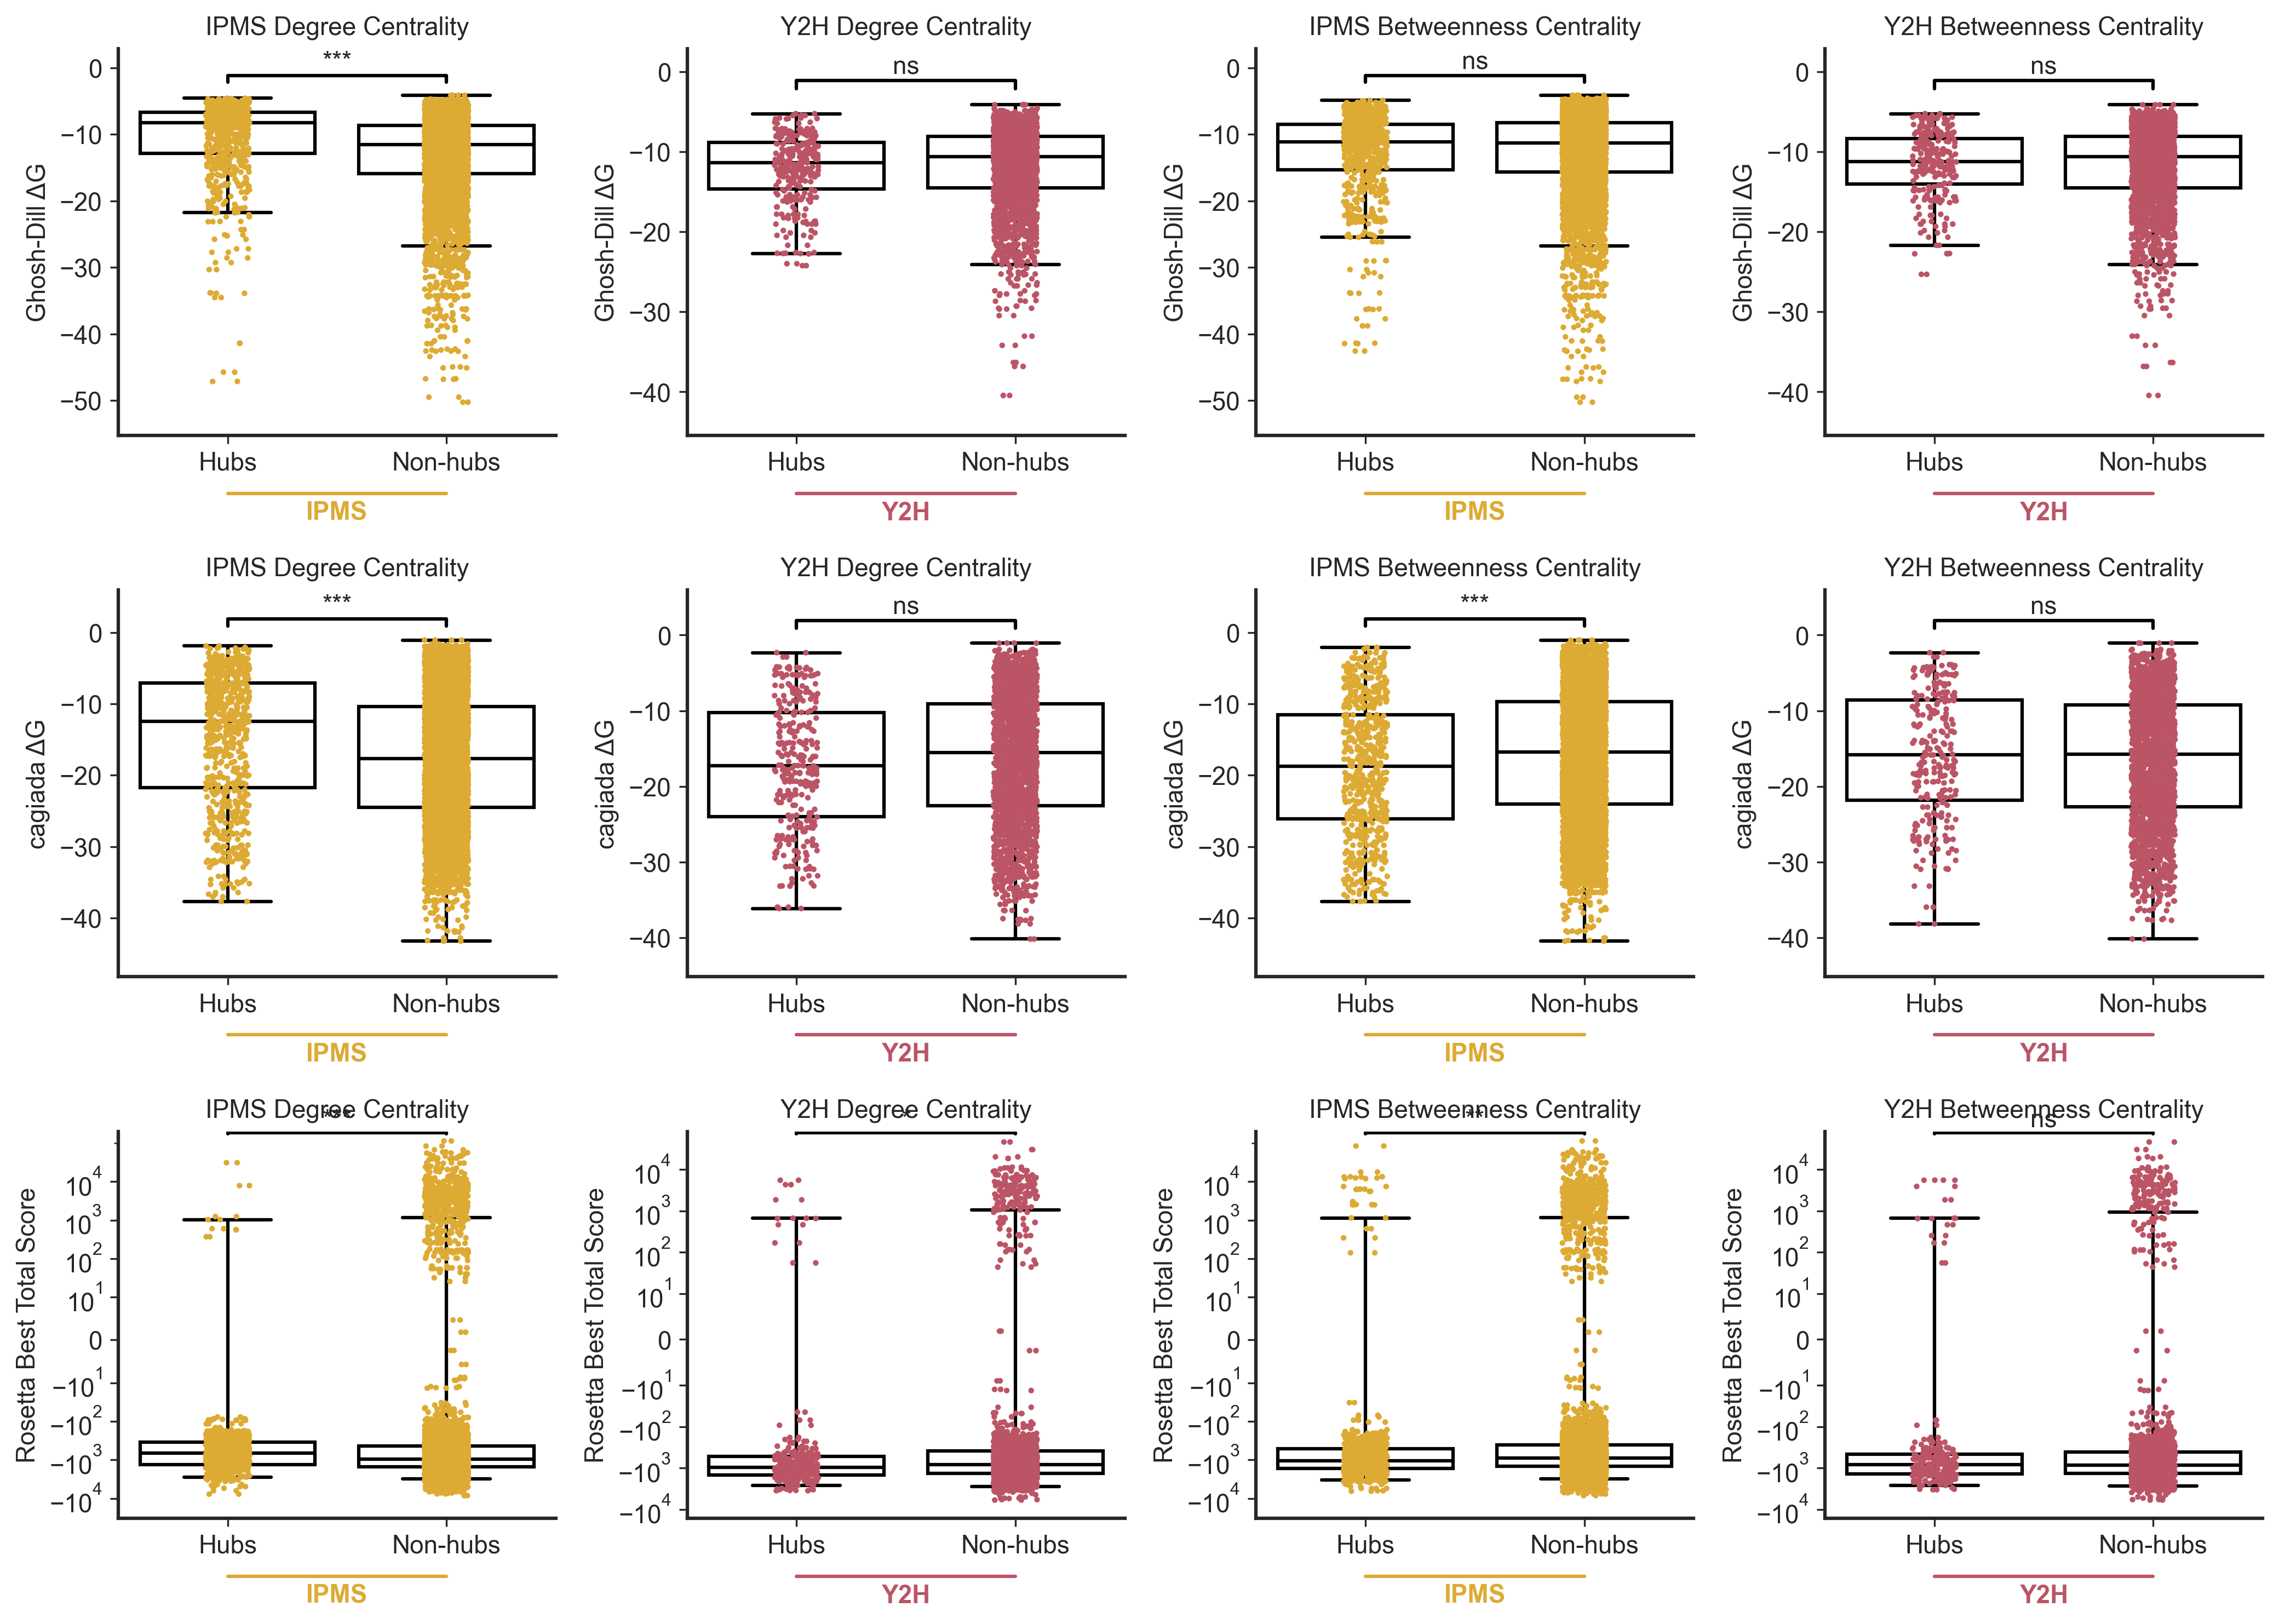

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ks_2samp
import os
import matplotlib.ticker as ticker
# Set global font settings for publication quality
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
def test_hub_stability_boxplot_single(selected_columns, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=True, print_stats=True):
    # === Define hub vs non-hub groups ===
    hubs = selected_columns[selected_columns[col] >= 90][stability_col].dropna()
    nonhubs = selected_columns[selected_columns[col] < 90][stability_col].dropna()
 
    # === Combine into a single dataframe ===
    data = pd.DataFrame({
        'Group': (['Hubs'] * len(hubs)) + (['Non-hubs'] * len(nonhubs)),
        'value': np.concatenate([hubs, nonhubs])
    })
 
    # === Mann–Whitney tests (on raw data, since values may be negative) ===
    if print_stats:
        print(f"\n=== Percentage Differences for {network_name} {metric_name} - {stability_name} ===")
        hubs_median = np.median(hubs)
        nonhubs_median = np.median(nonhubs)
        percentage = ((hubs_median - nonhubs_median) / nonhubs_median) * 100 if nonhubs_median != 0 else 0
        print(f"Hubs {network_name} are {percentage:.2f}% greater than Non-hubs {network_name} (medians: {hubs_median:.2f} vs {nonhubs_median:.2f})")
        print(f"\n=== Mann–Whitney U Tests for {network_name} {metric_name} - {stability_name} ===")
        tests = [
            ('Hubs vs Non-hubs', hubs, nonhubs)
        ]
        p_values = []
        for name, g1, g2 in tests:
            stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
            print(f"{name}: U={stat:.2f}, p={p:.4g}, n1={len(g1)}, n2={len(g2)}")
            p_values.append(p)
        print(f"\n=== Kolmogorov-Smirnov Tests for {network_name} {metric_name} - {stability_name} ===")
        for name, g1, g2 in tests:
            stat, p = ks_2samp(g1, g2)
            print(f"{name}: KS={stat:.2f}, p={p:.4g}, n1={len(g1)}, n2={len(g2)}")
    else:
        # Still compute p_values even if not printing
        tests = [
            (hubs, nonhubs)
        ]
        p_values = [mannwhitneyu(g1, g2, alternative='two-sided')[1] for g1, g2 in tests]
 
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
 
    # === Plot: swarm overlay + Boxplot ===
    sns.stripplot(
        data=data,
        x='Group',
        y='value', # Use original stability data
        palette={'Hubs': color, 'Non-hubs': color},
        size=2.5,
        alpha=1.0,
        jitter=True,
        ax=ax
    )
    sns.boxplot(
        data=data,
        x='Group',
        y='value', # Use original stability data
        palette={'Hubs': color, 'Non-hubs': color},
        showcaps=True,
        showfliers=False,
        fliersize=2,
        linewidth=1.5,
        boxprops={'edgecolor': 'black'},
        whiskerprops={'color': 'black', 'linewidth': 1.5},
        capprops={'color': 'black', 'linewidth': 1.5},
        medianprops={'color': 'black', 'linewidth': 1.5},
        width=0.8,
        ax=ax
    )
    for i, artist in enumerate(ax.patches):
        artist.set_facecolor('none')
        artist.set_edgecolor('black')
    sns.stripplot(
        data=data,
        x='Group',
        y='value', # Use original stability data
        palette={'Hubs': color, 'Non-hubs': color},
        size=2.5,
        alpha=1.0,
        jitter=True,
        ax=ax
    )
 
    ax.set_ylabel(stability_name)
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Hubs', 'Non-hubs'], rotation=0, ha='center')
 
    if stability_name == 'Rosetta Best Total Score':
        ax.set_yscale('symlog', linthresh=10)
        ax.set_yticks([-10000, -1000, -100, -10, 0, 10, 100, 1000, 10000])
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
 
    # === Determine if symlog and set offsets accordingly ===
    is_symlog = (stability_name == 'Rosetta Best Total Score')
    min_y = data['value'].min()
    max_y = data['value'].max()
    range_y = max_y - min_y if max_y != min_y else 1
    if is_symlog:
        y_start = max_y + range_y * 0.5
        v_offset = range_y * 0.1
        text_offset = v_offset * 0.3
        bar_spacing = range_y * 0.05  # Not used, but for consistency
        highest_y = y_start + v_offset + range_y * 0.1  # Buffer above top bar
        min_lim = min_y - range_y * 0.2
    else:
        y_start = max_y + 2
        v_offset = 1
        text_offset = 0.22
        bar_spacing = 2  # Not used, but for consistency
        highest_y = y_start + 5  # Buffer above top bar
        min_lim = min_y - 5
 
    # === Add significance bars ===
    def add_significance_bar(x1, x2, y, p_value, ax, force_ns=False):
        height = y
        bar_top = height + v_offset
        ax.plot([x1, x1, x2, x2], [height, bar_top, bar_top, height], lw=1.5, c='black')
        stars = 'ns' if force_ns or p_value >= 0.05 else '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
        ax.text((x1 + x2) * 0.5, bar_top + text_offset, stars, ha='center', va='bottom', fontfamily='Arial', fontsize=11)
 
    comparisons = [(0, 1, 0)]
    for idx, (x1, x2, test_idx) in enumerate(comparisons):
        force_ns = False
        add_significance_bar(x1, x2, y_start + idx * bar_spacing, p_values[test_idx], ax, force_ns=force_ns)
    ax.set_ylim(min_lim, highest_y)  # Adjust buffers based on scale
 
    # Add horizontal lines under MS and Y2H pairs
    ax.plot([0, 1], [-0.15, -0.15], color=color, lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.text(0.5, -0.17, network_name, ha='center', va='top', fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(), color=color, fontweight='bold')
 
    ax.set_title(f'{network_name} {metric_name}')
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
 
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        figure_label = '3B' # Adjust as needed, e.g., for figure panel
        save_path = os.path.join(save_dir, f'{figure_label}-stability-{network_name}-{metric_name.lower().replace(" ", "-")}-{stability_name.lower().replace(" ", "-")}.svg')
        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')
 
    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())
# === Example: loop over all four combinations and three stability metrics ===
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE3"
combinations = [
    ('MS_degree_centrality_percentile', 'IPMS', '#DDAA33', 'Degree Centrality'),
    ('Y2H_degree_centrality_percentile', 'Y2H', '#BB5566', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'IPMS', '#DDAA33', 'Betweenness Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Y2H', '#BB5566', 'Betweenness Centrality')
]
stability_metrics = [
    ('Ghosh-Dill-dG', 'Ghosh-Dill ΔG'),
    ('cagiada-dG', 'cagiada ΔG'),
    ('Rosetta_best_total_score', 'Rosetta Best Total Score')
]
# Save individual plots (with stats printed)
for stability_col, stability_name in stability_metrics:
    for col, network_name, color, metric_name in combinations:
        test_hub_stability_boxplot_single(filtered_df, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=False, print_stats=True)
# Optional: Display in a 3x4 grid (one row per stability metric, no additional prints)
fig, axs = plt.subplots(3, 4, figsize=(14, 10)) # 3 stability metrics x 4 combinations
for i, (stability_col, stability_name) in enumerate(stability_metrics):
     for j, (col, network_name, color, metric_name) in enumerate(combinations):
         test_hub_stability_boxplot_single(
             filtered_df, col, network_name, color, save_dir, metric_name, stability_col, stability_name,
             ax=axs[i, j], save=False, show=False, print_stats=False
         )
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()